In [6]:
from google.colab import drive
drive.mount('/content/drive/')

# Load data and Pre-processing

In [ ]:
#Set your project path & file name 
# project_path = '/content/drive/My Drive/ML_Project/Capstone/'
project_path = '/content/drive/My Drive/Capstone_NLP/'
file_name ='IT-Ticket-Classification.xlsx'

import pandas as pd 
import numpy as np 
import re 
import sys
itTicketDF=pd.read_excel(project_path+file_name,encoding=sys.getfilesystemencoding())
itTicketDF.head()

callers = itTicketDF['Caller'].unique() 
callers.shape
itTicketDF.drop(["Caller",'Short description'],axis=1,inplace= True)
itTicketDF.info()

ModuleNotFoundError: No module named 'pandas'

ModuleNotFoundError: No module named 'pandas'

: 

In [ ]:
targetClassCnt=itTicketDF['Assignment group'].value_counts()
targetClassCnt.describe()

count      74.000000
mean      114.864865
std       465.747516
min         1.000000
25%         5.250000
50%        26.000000
75%        84.000000
max      3976.000000
Name: Assignment group, dtype: float64

### **Observation**
*  Appears the Target class distrubtion is extremely skewed
*  Large no of entries for GRP_0 (mounting to 3976) which account for ~50% of the data
*  there are groups with 1 entry also. We could merge all groups with small entries to a group to reduce the imbalance in the target. This may reduce the imbalance to some extent.

In [ ]:
sample = itTicketDF.groupby(['Assignment group'])
regroup=[]
for grp in itTicketDF['Assignment group'].unique():
  if(sample.get_group(grp).shape[0]<10):
    regroup.append(grp)
print('Found {} groups which have under 10 samples'.format(len(regroup)))
itTicketDF['Assignment group']=itTicketDF['Assignment group'].apply(lambda x : 'misc_grp' if x in regroup  else x)

# Unique Groups check 
itTicketDF['Assignment group'].unique()

Found 25 groups which have under 10 samples


array(['GRP_0', 'GRP_1', 'GRP_3', 'GRP_4', 'GRP_5', 'GRP_6', 'GRP_7',
       'GRP_8', 'GRP_9', 'GRP_10', 'GRP_11', 'GRP_12', 'GRP_13', 'GRP_14',
       'GRP_15', 'GRP_16', 'GRP_17', 'GRP_18', 'GRP_19', 'GRP_2',
       'GRP_20', 'GRP_21', 'GRP_22', 'GRP_23', 'GRP_24', 'GRP_25',
       'GRP_26', 'GRP_27', 'GRP_28', 'GRP_29', 'GRP_30', 'GRP_31',
       'GRP_33', 'GRP_34', 'misc_grp', 'GRP_36', 'GRP_37', 'GRP_39',
       'GRP_40', 'GRP_41', 'GRP_42', 'GRP_44', 'GRP_45', 'GRP_47',
       'GRP_48', 'GRP_50', 'GRP_53', 'GRP_60', 'GRP_62', 'GRP_65'],
      dtype=object)

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


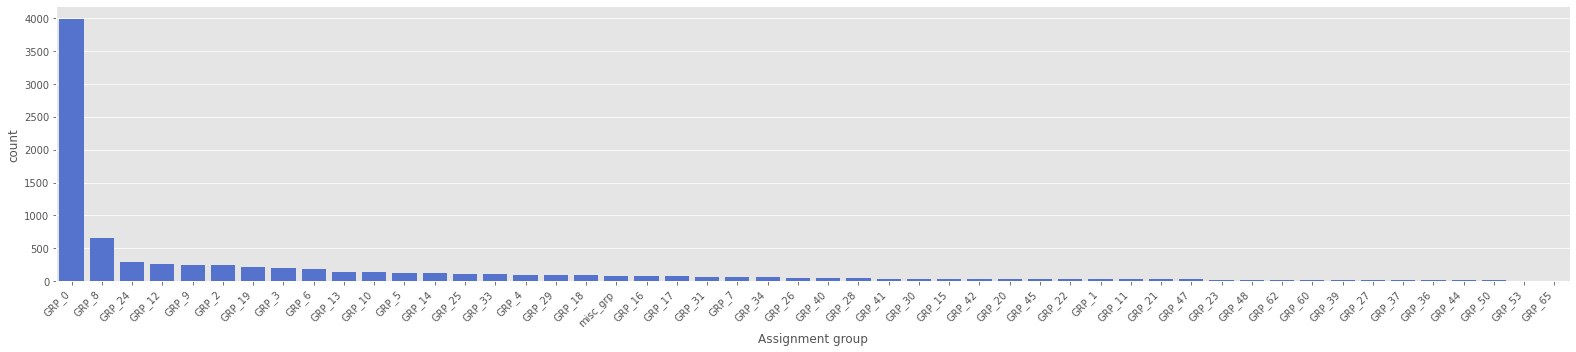

In [ ]:
##Pre-Processing label Encoding on  Assignment Group
import seaborn as sns
import matplotlib.pyplot as plt
#add to remove warning for python 3.6 dependency
import warnings
import pandas.util.testing as tm
plt.style.use('ggplot')
%matplotlib inline

descending_order = itTicketDF['Assignment group'].value_counts().sort_values(ascending=False).index
plt.subplots(figsize=(22,5))
#added code for x label rotate 
ax=sns.countplot(x='Assignment group', data=itTicketDF, color='royalblue',order=descending_order)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Data Cleansing

In [0]:
#Fill 'Decsription' field entries that have null with blank space
itTicketDF['Description'].fillna(value=' ', inplace=True)

In [0]:
from dateutil import parser
def is_valid_date(date_str):
    try:
        parser.parse(date_str)
        return True
    except:
        return False

def clean_data(text):
    text=text.lower()
    text = ' '.join([w for w in text.split() if not is_valid_date(w)])
    text = re.sub(r"received from:",' ',text)
    text = re.sub(r"from:",' ',text)
    text = re.sub(r"to:",' ',text)
    text = re.sub(r"subject:",' ',text)
    text = re.sub(r"sent:",' ',text)
    text = re.sub(r"ic:",' ',text)
    text = re.sub(r"cc:",' ',text)
    text = re.sub(r"bcc:",' ',text)
    #Remove email 
    text = re.sub(r'\S*@\S*\s?', '', text)
    # Remove numbers 
    text = re.sub(r'\d+','' ,text)
    # Remove Non Dictionary character-TODO
    # Remove new line characters 
    text = re.sub(r'\n',' ',text)
    # Remove hashtag while keeping hashtag text
    text = re.sub(r'#','', text)
    #& 
    text = re.sub(r'&;?', 'and',text)
    # Remove HTML special entities (e.g. &amp;)
    text = re.sub(r'\&\w*;', '', text)
    # Remove hyperlinks
    text = re.sub(r'https?:\/\/.*\/\w*', '', text)  
    # Remove characters beyond Readable formart by Unicode:
    text= ''.join(c for c in text if c <= '\uFFFF') 
    text = text.strip()
    # Remove unreadable characters  (also extra spaces)
    text = ' '.join(re.sub("[^\u0030-\u0039\u0041-\u005a\u0061-\u007a]", " ", text).split())
    for name in callers:
      namelist = [part for part in name.split()]
      for namepart in namelist: 
          text = text.replace(namepart,'')
          
    text = re.sub(r"\s+[a-zA-Z]\s+", ' ', text)
    text = re.sub(' +', ' ', text)
    text = text.strip()
    return text
  
itTicketDF['Description'] = itTicketDF['Description'].apply(clean_data)

In [ ]:
itTicketDF['length']=[len(text) for text in itTicketDF['Description']]
itTicketDF=itTicketDF[itTicketDF['length']>=3]
itTicketDF['Description'] = itTicketDF['Description'].apply(lambda x : " ".join([word for word in x.split() if(len(word)>2)]))

#itTicketDF.drop(['length'],axis=1,inplace= True)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


## Translation

In [ ]:
germanwordlist = ['bitte','nicht','konto','probleme','berechtigung','defekt','mehr','ausgetauscht','rechner', 'drucker','teilweise','freigegeben','genannten','anmeldeaccount',
                  'besprochen','werden','durchwahl','oben','einrichten','zeitwirtschaft','seit','morgens','beheben','keine','zeitbuchungen','vorhanden','dringend','fehler',
                  'werk','anmelde','auftrag','kein','skannen','freundlichen','werkzeuge,','hartstoffe','maste','schutzw','fertigung','immer','sehr','zugriff','freundliche',
                  'geehrter','souzarft','noch','verbindungsherstellung','meldung','erneuten','glich','proben','beilageproben','beilage','auswerten','sinterleitstand','reparar',
                  'reparo','rechner','koenigsee','entregar','atualiza','declara','programdntya','funcionando','preciso','hitacni','grergtger','zugriffsrechte','teamleiter',
                  'abholen','wegen','weit','absender','wenn','abrechnung']
pattern = '|'.join(germanwordlist)

pattern

'bitte|nicht|konto|probleme|berechtigung|defekt|mehr|ausgetauscht|rechner|drucker|teilweise|freigegeben|genannten|anmeldeaccount|besprochen|werden|durchwahl|oben|einrichten|zeitwirtschaft|seit|morgens|beheben|keine|zeitbuchungen|vorhanden|dringend|fehler|werk|anmelde|auftrag|kein|skannen|freundlichen|werkzeuge,|hartstoffe|maste|schutzw|fertigung|immer|sehr|zugriff|freundliche|geehrter|souzarft|noch|verbindungsherstellung|meldung|erneuten|glich|proben|beilageproben|beilage|auswerten|sinterleitstand|reparar|reparo|rechner|koenigsee|entregar|atualiza|declara|programdntya|funcionando|preciso|hitacni|grergtger|zugriffsrechte|teamleiter|abholen|wegen|weit|absender|wenn|abrechnung'

In [ ]:
germanDescIndex = itTicketDF[itTicketDF['Description'].str.contains(pattern)].index
germanDescIndex

Int64Index([ 223,  238,  251,  255,  265,  270,  272,  302,  304,  305,
            ...
            8414, 8417, 8419, 8420, 8425, 8427, 8436, 8439, 8467, 8499],
           dtype='int64', length=586)

In [ ]:
# since translation done by googletrans & textblob is giving error while using checking & translating every row, just checking the "Description" for german word like 'bitte'

#Install google translator by pip if not installed
!pip install -q googletrans
from googletrans import Translator

def translateIfRequired(x):
    translator = Translator()
    if translator.detect(x).lang != 'en':
        translatedText = translator.translate(x).text
    else:
        translatedText = x
    return translatedText

In [ ]:
for rowId in germanDescIndex:
    itTicketDF['Description'][rowId] = translateIfRequired(itTicketDF['Description'][rowId])

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/usr/local/lib/python3.6/dist-packages/IPython/core/interactiveshell.py:2882: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
germanDescIndex_new = itTicketDF[itTicketDF['Description'].str.contains(pattern)].index
germanDescIndex_new

Int64Index([ 238,  446,  874,  914,  932,  995, 1134, 1175, 1233, 1275,
            ...
            7782, 7809, 7832, 7912, 8214, 8216, 8232, 8237, 8427, 8436],
           dtype='int64', length=127)

In [ ]:
itTicketDF['Description'][8232]

'stepfhryhan needs access below Collaboration Platform left vacation planning file efdl users Linnaeus collaboration platform company inc team folder linnemann vacation planning file efdl users Linnaeus collaboration platform company inc team folder linnemann ene general file efdl users Linnaeus collaboration platform company inc team folder linnemann general berirtchtswesen area North file efdl users Linnaeus collaboration platform company inc team folder linnemann berirtchtswesen area north crm team folder file efdl users Linne collaboration platform company inc team folder linnemann crm team folder team call team meeting file efdl users Linne collaboration platform company inc team folder linnemann team call team meeting top projects file efdl users Linne collaboration platform company inc team folder linnemann top projects hello sabrthy how far we have this topic not yet received ticket with friendly application engineer application engineer company gmbh Germany this message is sol

## Combine Description and Short Description

In [ ]:
itTicketDF.reset_index(drop=True,inplace=True)

itTicketDF['Description'] = itTicketDF['Description'].str.strip()
itTicketDF['Description'] = itTicketDF['Description'].str.lower()

from collections import OrderedDict
itTicketDF['Description']=itTicketDF['Description'].str.split().apply(lambda x:OrderedDict.fromkeys(x).keys()).str.join(' ')
itTicketDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8439 entries, 0 to 8438
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Description       8439 non-null   object
 1   Assignment group  8439 non-null   object
 2   length            8439 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 197.9+ KB


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

## Lemmatisation and stop words removal

In [ ]:
from nltk.corpus import stopwords
import nltk
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger') 

sr = stopwords.words('english')
for i,text in enumerate(itTicketDF['Description']):
  itTicketDF['Description'][i]=" ".join(word for word in text.split(' ') if word not in sr)

# install spacy and plt for gensim  
!pip install -q spacy 
import spacy
nlp = spacy.load('en', disable=['parser', 'ner'])
allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']
def lemmatize_text(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc])

itTicketDF['Description'] = itTicketDF['Description'].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Remove the CWD from sys.path while we load stuff.
/usr/local/lib/python3.6/dist-packages/IPython/core/interactiveshell.py:2882: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exec(code_obj, self.user_global_ns, self.user_ns)
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

In [ ]:
itTicketDF['Description'][8232]

'abended job scheduler'

# Perform Spell check

In [0]:
# !pip install pyspellchecker

# from spellchecker import SpellChecker

# def correctSpelling(text):
#     spell = SpellChecker()
#     spell.word_frequency.load_words(['netweaver','-pron-','caas','hostname','unmonitored','activesync','audiocode','isp','apac','skype','callie','worklist','gsc','verizon',
#                                      'firewall','wifi','downloader','uploaded','crm','mms','iphone','rgds','thx','inbox','prefetch','mbps','website','www','inplant','openstage',
#                                      'costcenter','undeliverable','svC','emea','html','reinstall','upload','jpg','signout','malware','cvss','rar','xls','uplink','ziped','uncaught',
#                                      'xlsx','wlan','webpage','uploader','firefox','callback','acct','abap','svchost','webserviceclient','wlc','sid'])
#     wordlist = [word for word in text.split()]
#     misspelled = spell.unknown(wordlist)
#     for incorrect in misspelled:
#         correct = spell.correction(incorrect)
#         text = text.replace(incorrect, correct)
#     return text

# itTicketDF['Description'] = itTicketDF['Description'].apply(correctSpelling)

### Observation:
- Initial thoughts were to combine the short description & description fields so that the a more comrehensive vocabulary is generated. But this caused sentences to have foreign language & english being combined. This became a deterent in language translation. 
- On checking model accuracy we observed neglible difference when 'Shot Description' was included.
- Similar while performing spell check also, it was observed that model accuracy was not improving. Hence decided against doing this considering the huge time taken to perform the task by pyspellchecker. 

# Topic Modeling


1.   Use Sapcy for lemmatistaion 
2.   Use PyLDAvis for the plot to provide good info on clustering.
3.   Use NLTk explicitly (stop word removal)on each Value in text_combined . 
4.   Use bigram model to cluster relevant data together usings genSIM. 



In [ ]:
!pip install -q pyLDAvis 

     |████████████████████████████████| 1.6MB 2.7MB/s 
     |████████████████████████████████| 552kB 19.4MB/s 


In [0]:
# Gensim
import gensim
import gensim.corpora as corpora
#Remove stemming(snowball stemming) add lemmatistaion using simple_process from gensim 
from gensim.utils import simple_preprocess
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel

# spacy for lemmatization
import spacy

# Plotting tools
import pyLDAvis
import pyLDAvis.gensim  # don't skip this 
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [0]:
#to process the simple_process gensim package as input needed as string 
combined_text=itTicketDF.Description.values.tolist()

In [ ]:
combined_text[1]

'hello team meeting skype etc appear outlook calendar somebody please advise correct kind'

In [0]:
#Convert  Combined text from each sentense to the words. use of simple_process as it tokenize() internally
#https://radimrehurek.com/gensim/utils.html#gensim.utils.simple_preprocess
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))  # deacc=True removes punctuations

data_words = list(sent_to_words(combined_text))

In [ ]:
print(data_words[1])

['hello', 'team', 'meeting', 'skype', 'etc', 'appear', 'outlook', 'calendar', 'somebody', 'please', 'advise', 'correct', 'kind']


In [ ]:
# Build the bigram and trigram models
#https://radimrehurek.com/gensim/models/phrases.html
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100) # higher threshold fewer phrases.
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)  

# Faster way to get a sentence clubbed as a trigram/bigram
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

/usr/local/lib/python3.6/dist-packages/gensim/models/phrases.py:598: UserWarning: For a faster implementation, use the gensim.models.phrases.Phraser class
  warnings.warn("For a faster implementation, use the gensim.models.phrases.Phraser class")


In [ ]:
print(bigram_mod[data_words[1]])

['hello', 'team', 'meeting', 'skype', 'etc', 'appear', 'outlook', 'calendar', 'somebody', 'please', 'advise', 'correct', 'kind']


In [ ]:
# See trigram example
print(trigram_mod[bigram_mod[data_words[1]]])

['hello', 'team', 'meeting', 'skype', 'etc', 'appear', 'outlook', 'calendar', 'somebody', 'please', 'advise', 'correct', 'kind']


In [0]:
def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

In [0]:
# Form Bigrams
data_words_bigrams = make_bigrams(data_words)

In [ ]:
print(data_words_bigrams[1])

['hello', 'team', 'meeting', 'skype', 'etc', 'appear', 'outlook', 'calendar', 'somebody', 'please', 'advise', 'correct', 'kind']


##### WordCloud usage 

In [0]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [0]:
wordclouds=' '.join(map(str, data_words_bigrams)) 

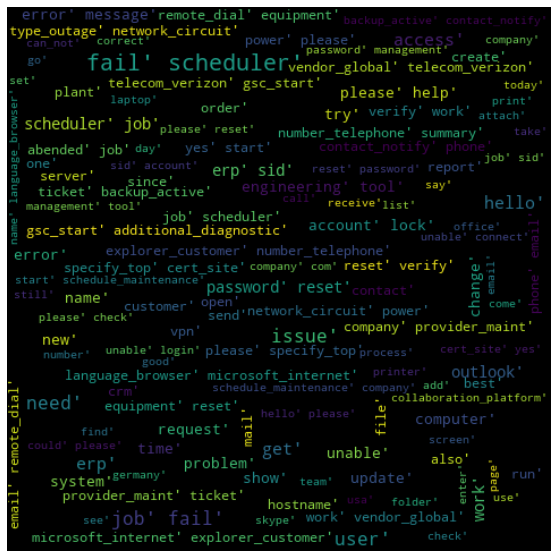

In [ ]:
wordcloud = WordCloud(width=480, height=480, max_font_size=20, min_font_size=10).generate(wordclouds)
plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()


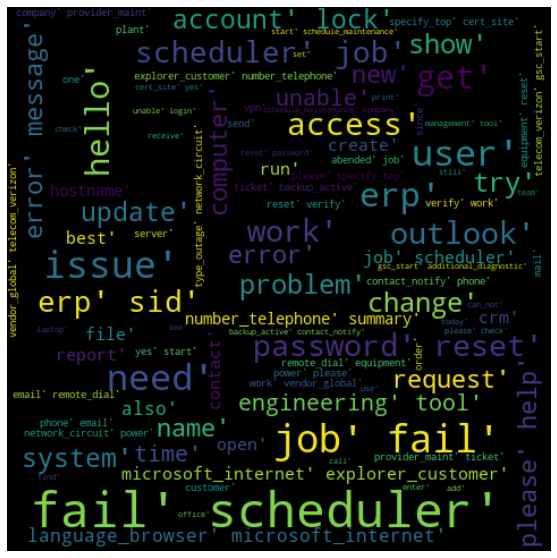

In [ ]:
#check for the word count 100)
wordcloud_2 = WordCloud(width=480, height=480, max_words=100).generate(wordclouds)
plt.figure(figsize=(10,10))
plt.imshow(wordcloud_2, interpolation="bilinear")
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

In [ ]:
#Copying to new dataframe to create wordclouds on target class

new_df = itTicketDF.copy()
new_df['words'] = data_words_bigrams
new_df

,Description,Assignment group,length,words
0,verify user detail employee manager name check...,GRP_0,192,"[verify, user, detail, employee, manager, name..."
1,hello team meeting skype etc appear outlook ca...,GRP_0,134,"[hello, team, meeting, skype, etc, appear, out..."
2,can not log vpn best,GRP_0,28,"[can_not, log, vpn, best]"
3,unable access tool page,GRP_0,29,"[unable, access, tool, page]"
4,skype error,GRP_0,11,"[skype, error]"
...,...,...,...,...
8434,good afternoon receive email send mail please ...,GRP_29,79,"[good_afternoon, receive, email, send, mail, p..."
8435,telephony software issue,GRP_0,24,"[telephony_software, issue]"
8436,vip windows password reset tifpdchb pedxruyf,GRP_0,48,"[vip, windows, password, reset, tifpdchb, pedx..."
8437,unable access machine utility finish drawer ad...,GRP_62,99,"[unable, access, machine, utility, finish, dra..."


In [ ]:
#Sorting based on frequency of target class Assignment group

value = new_df['Assignment group'].value_counts().sort_values(ascending=False).index
value

Index(['GRP_0', 'GRP_8', 'GRP_24', 'GRP_12', 'GRP_9', 'GRP_2', 'GRP_19',
       'GRP_3', 'GRP_6', 'GRP_13', 'GRP_10', 'GRP_5', 'GRP_14', 'GRP_25',
       'GRP_33', 'GRP_4', 'GRP_29', 'GRP_18', 'misc_grp', 'GRP_16', 'GRP_17',
       'GRP_7', 'GRP_31', 'GRP_34', 'GRP_26', 'GRP_40', 'GRP_28', 'GRP_41',
       'GRP_15', 'GRP_42', 'GRP_20', 'GRP_45', 'GRP_1', 'GRP_22', 'GRP_11',
       'GRP_21', 'GRP_47', 'GRP_62', 'GRP_23', 'GRP_60', 'GRP_39', 'GRP_30',
       'GRP_27', 'GRP_37', 'GRP_36', 'GRP_44', 'GRP_50', 'GRP_65', 'GRP_53',
       'GRP_48'],
      dtype='object')

In [0]:
# Creating a function for wordcloud
def wordcloud_grp(f, x):
    wordclouds_0=' '.join(map(str, f))

    wc = WordCloud(width=480, height=480, max_font_size=20, min_font_size=10, max_words=50).generate(wordclouds_0)
    plt.figure(figsize=(20,10))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Most common 50 words of {}".format(x))
    plt.margins(x=0, y=0)
    plt.show()

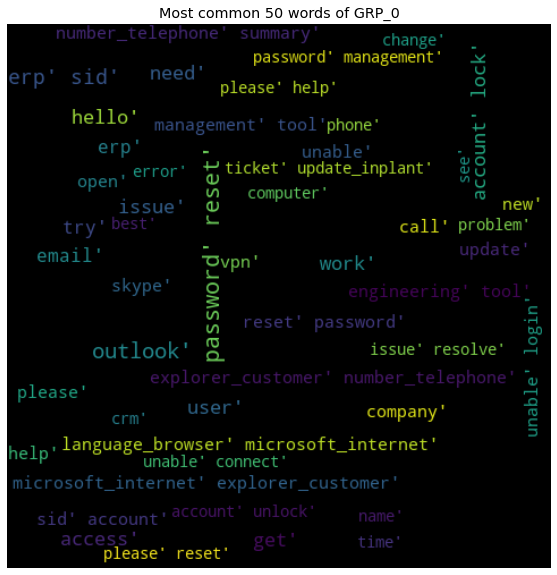

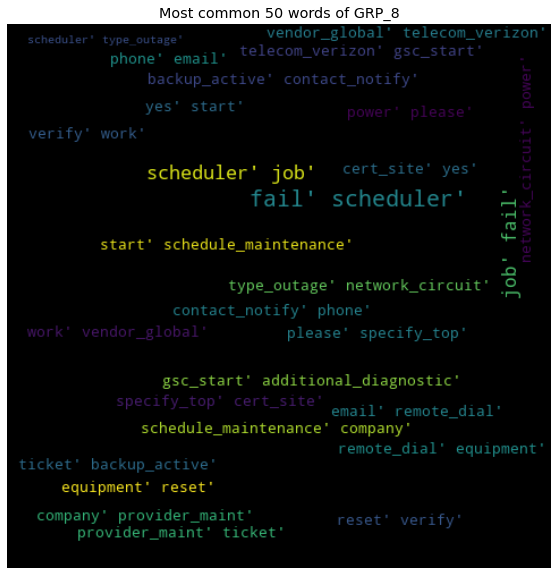

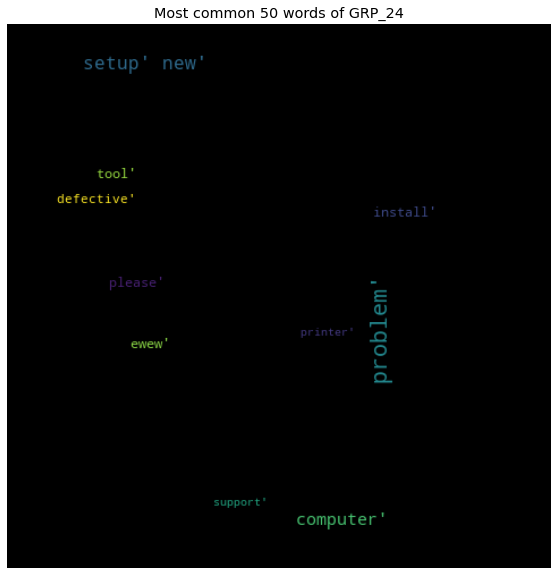

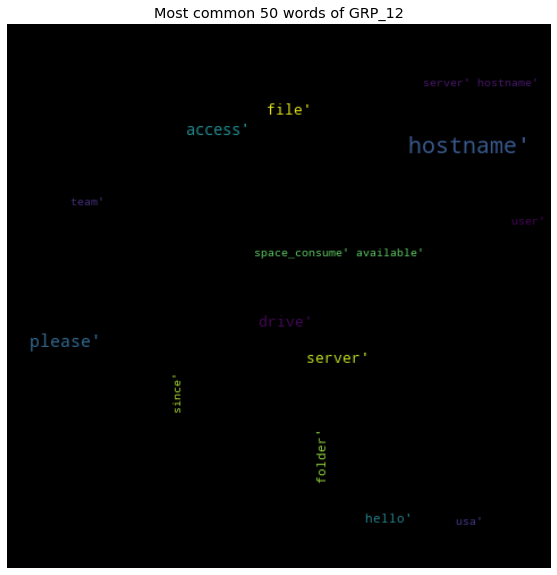

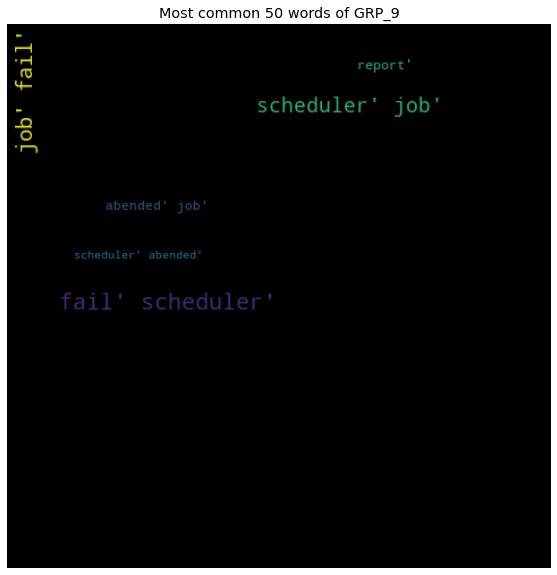

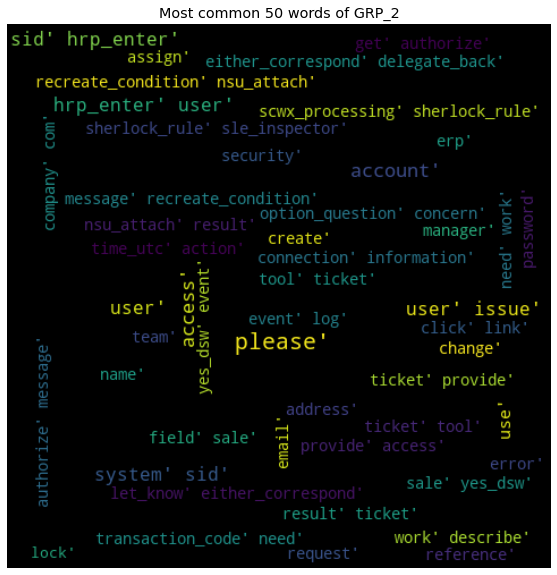

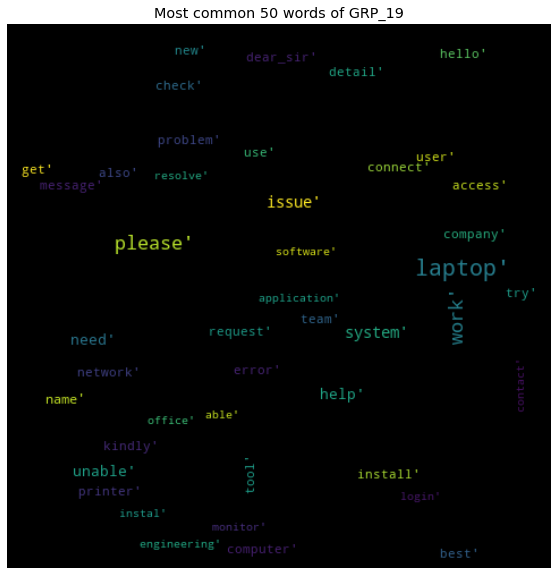

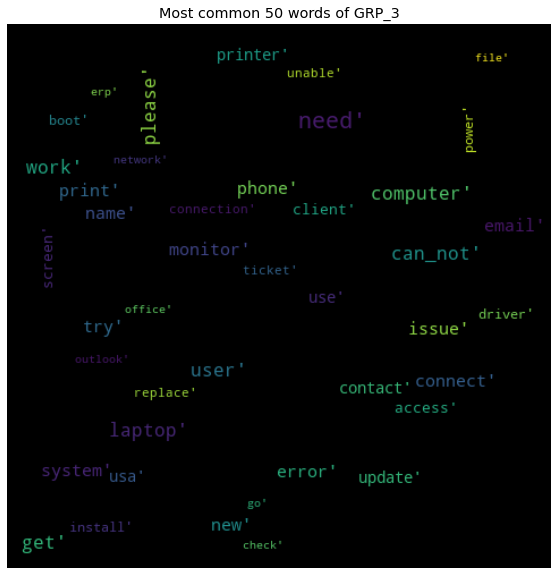

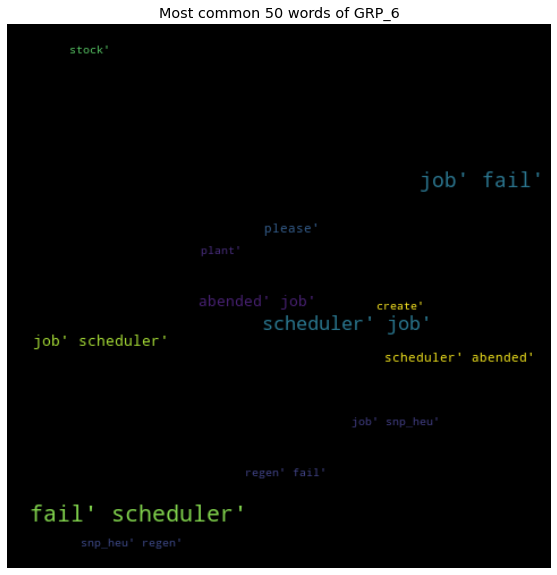

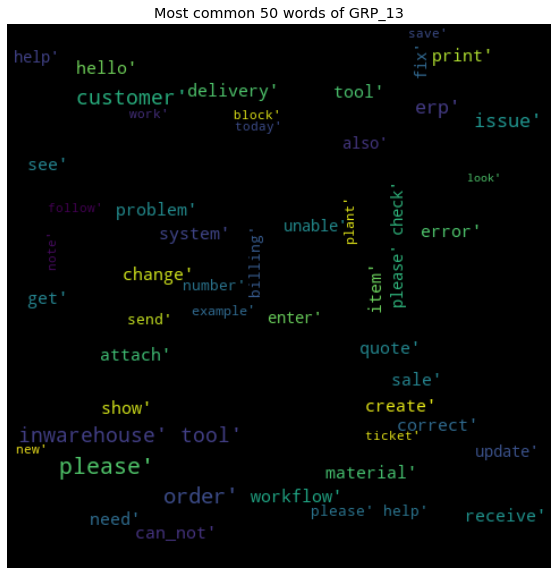

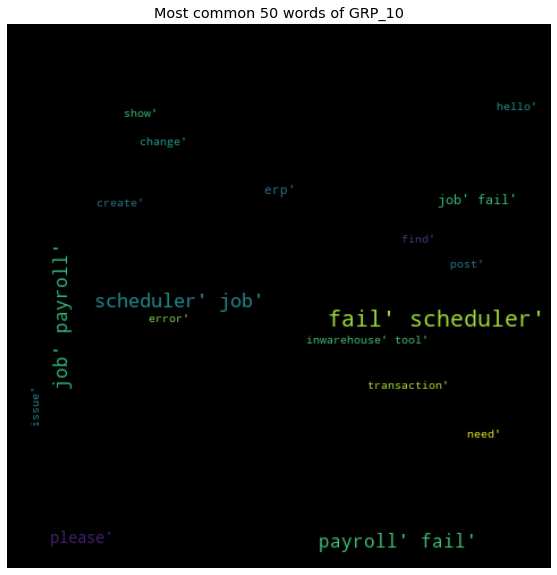

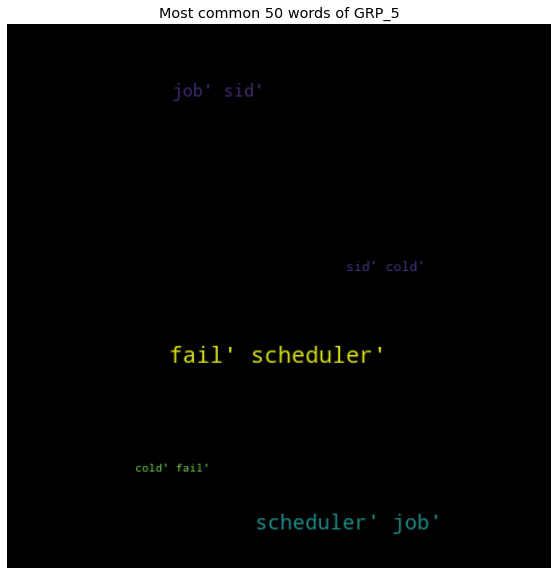

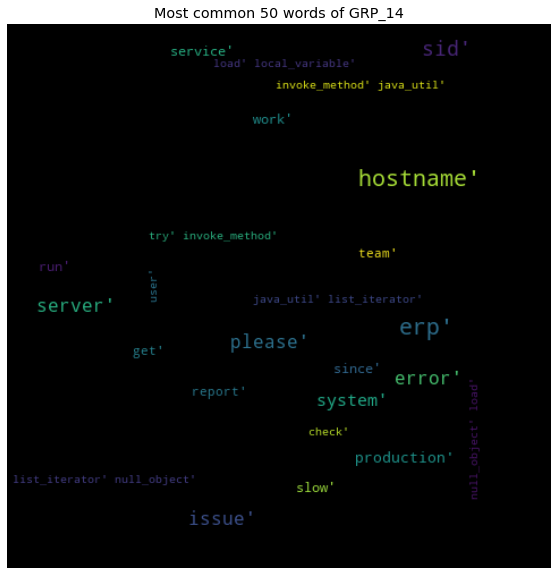

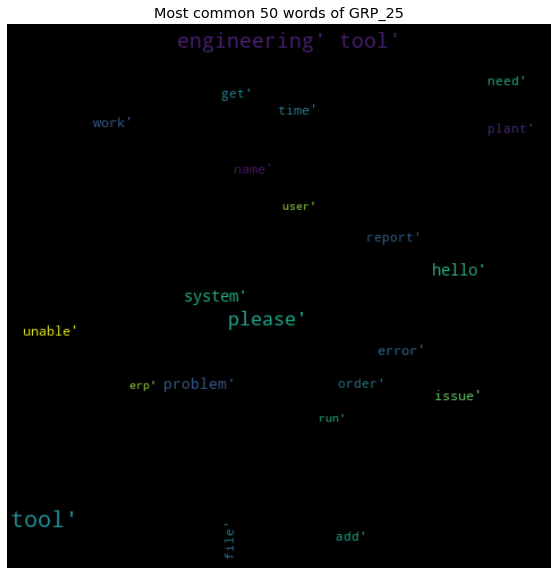

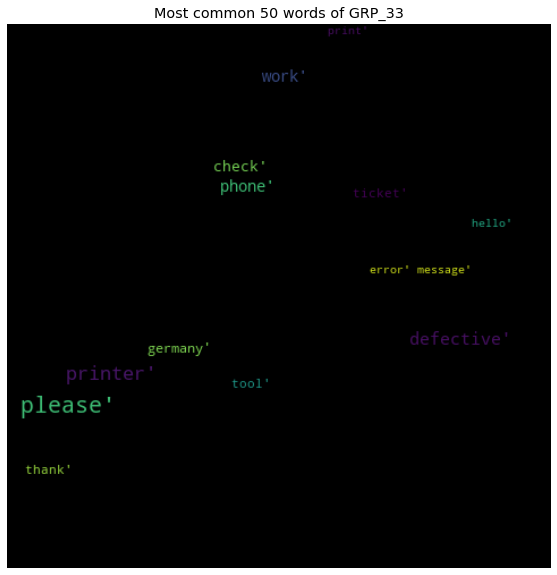

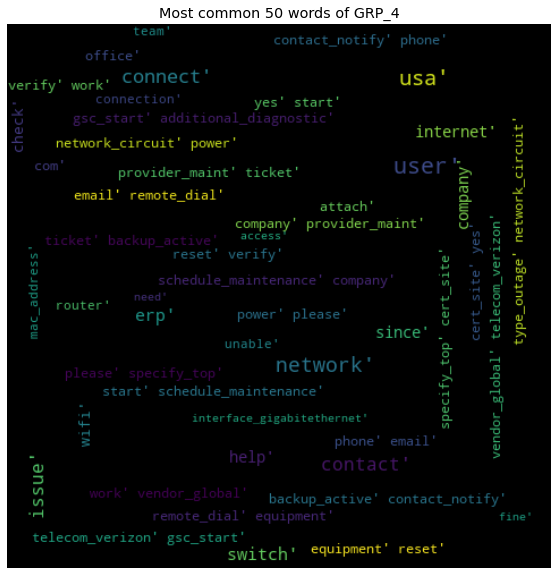

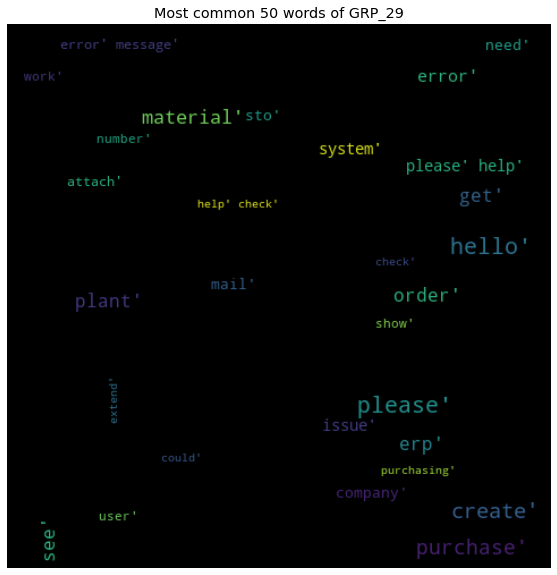

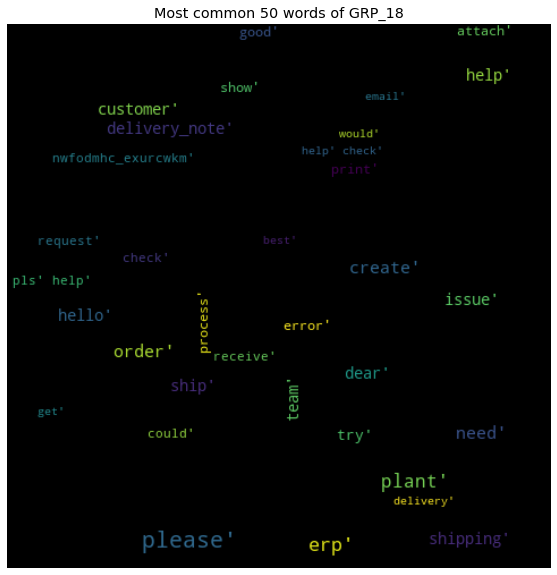

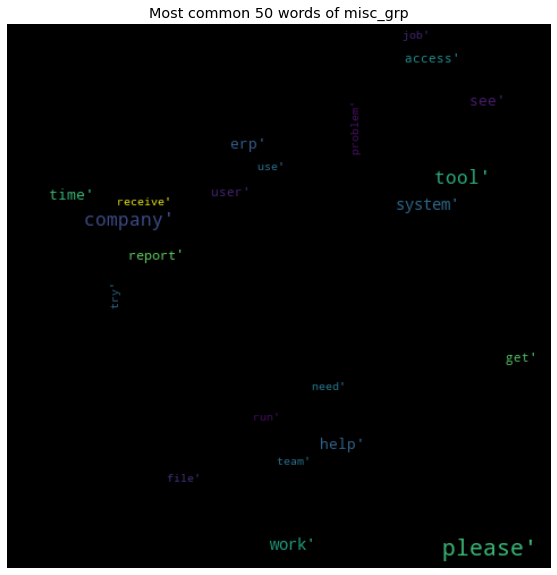

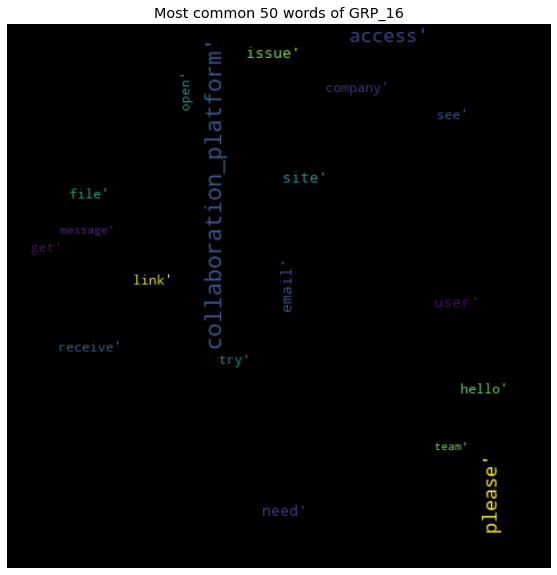

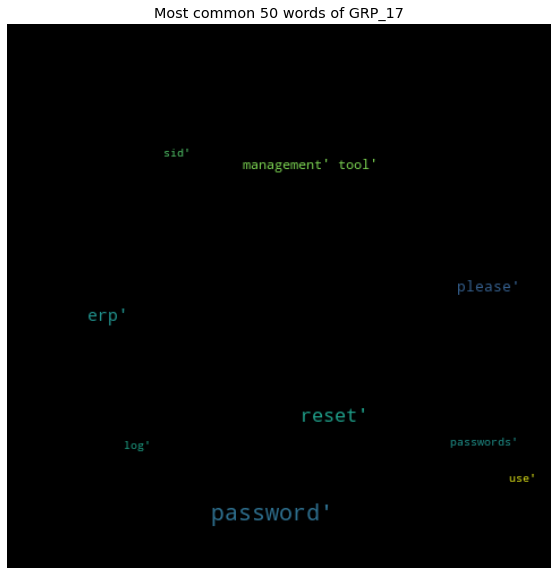

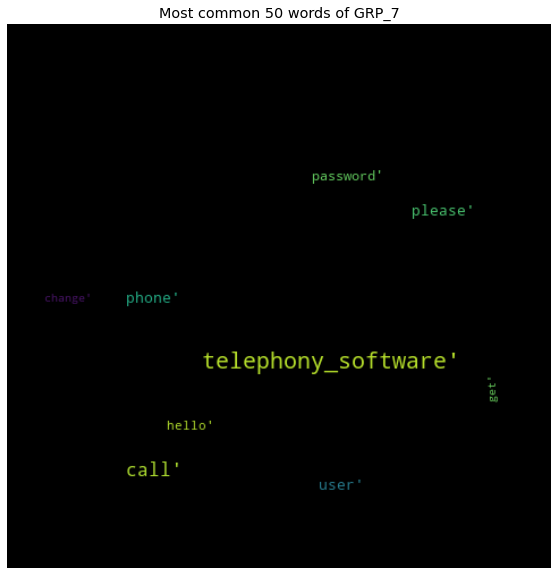

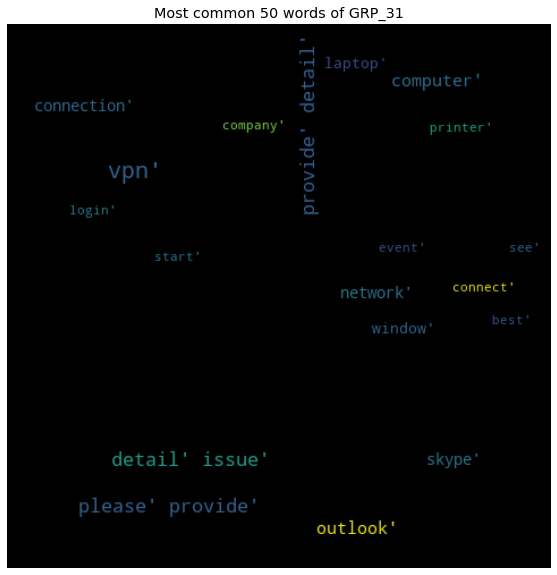

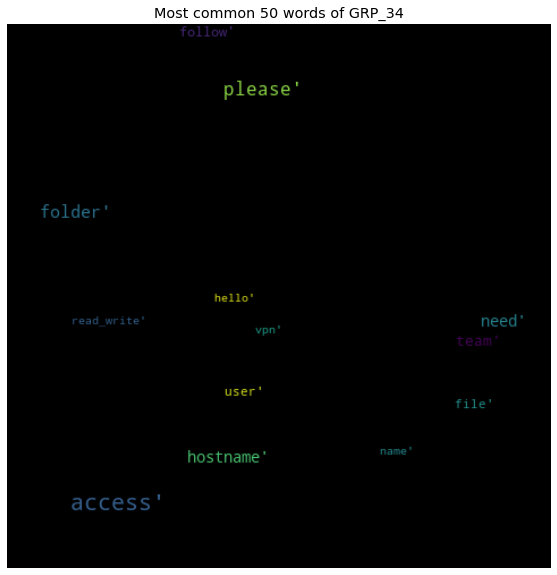

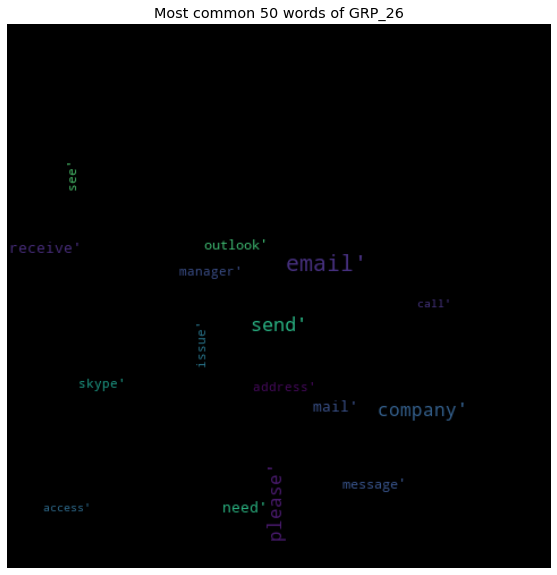

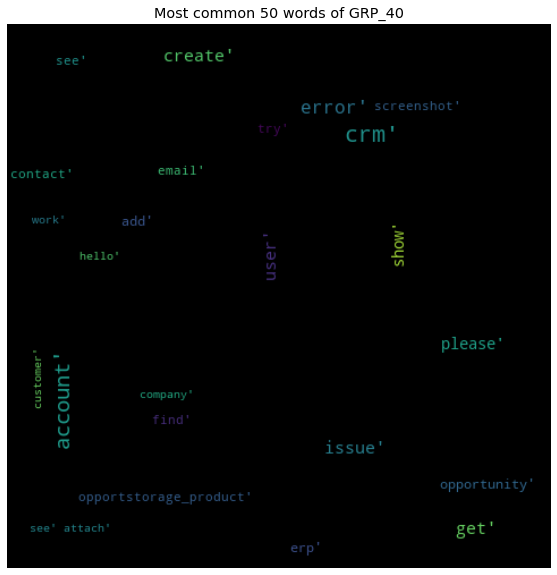

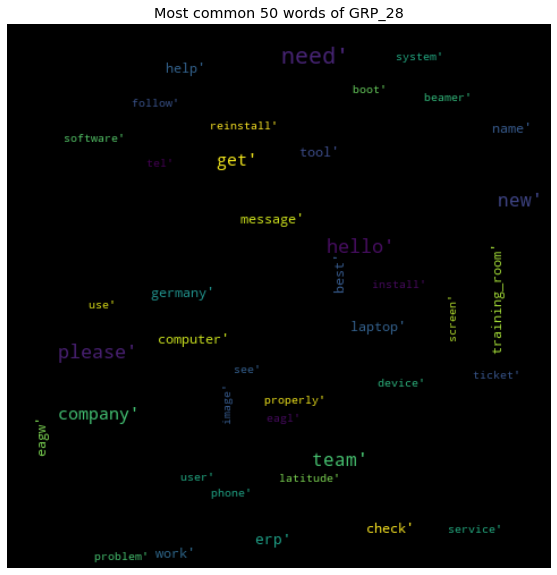

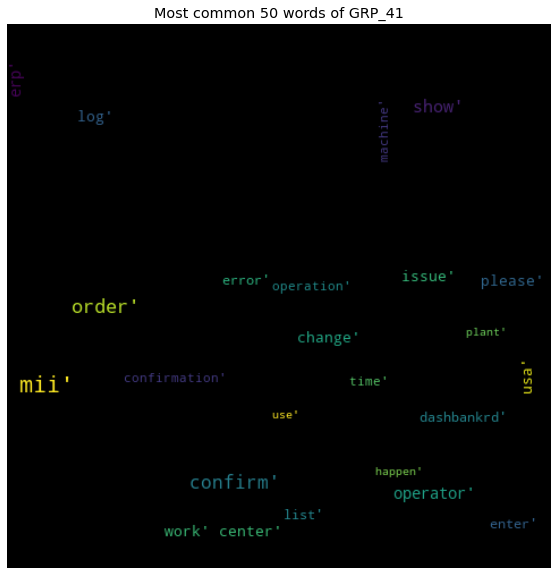

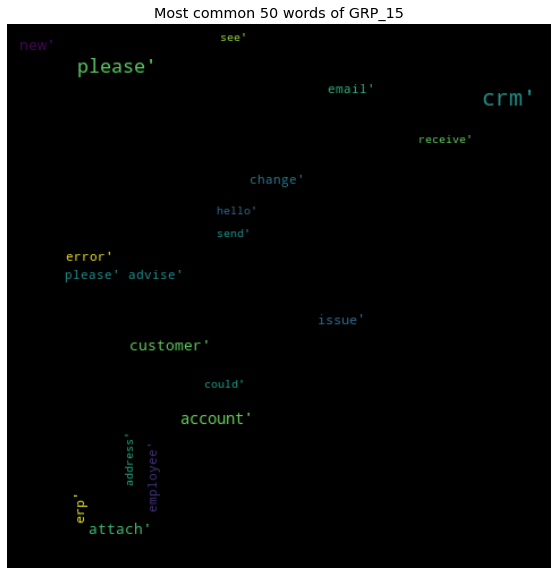

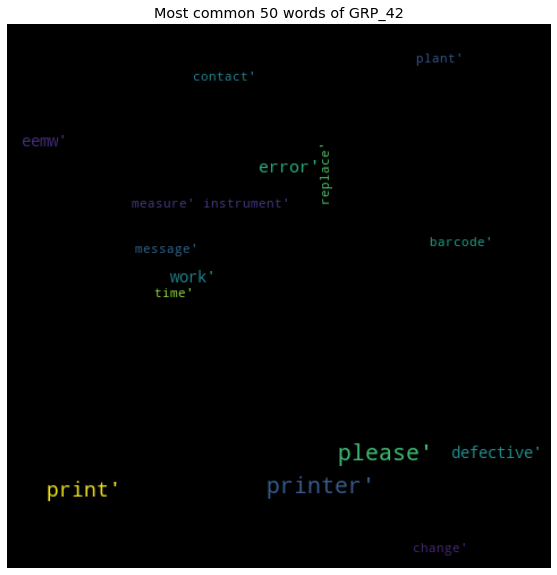

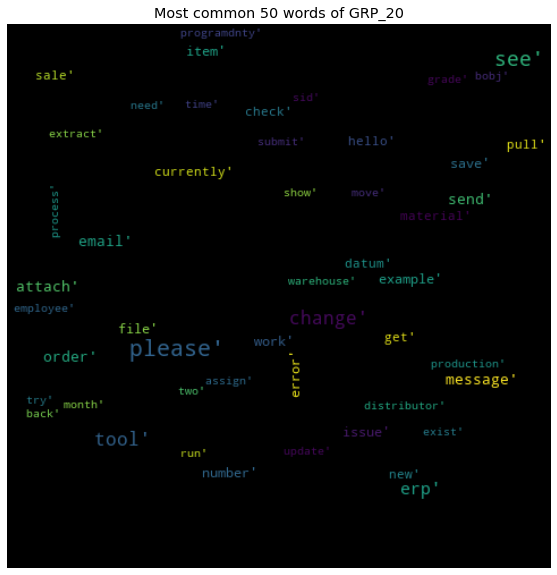

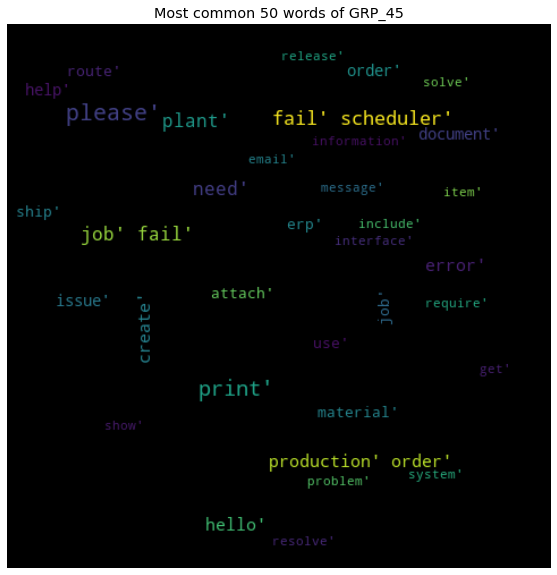

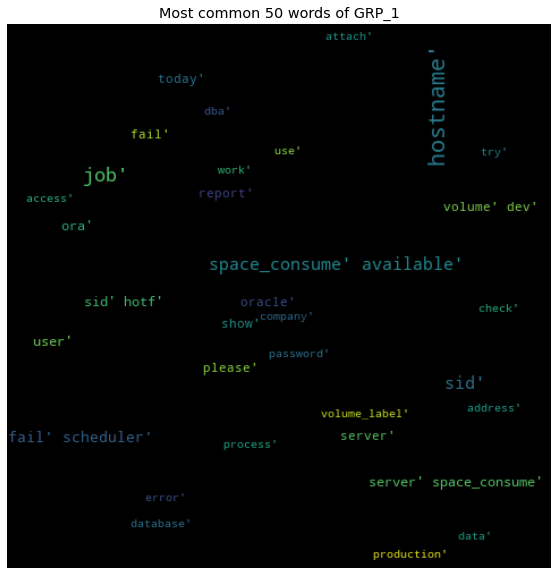

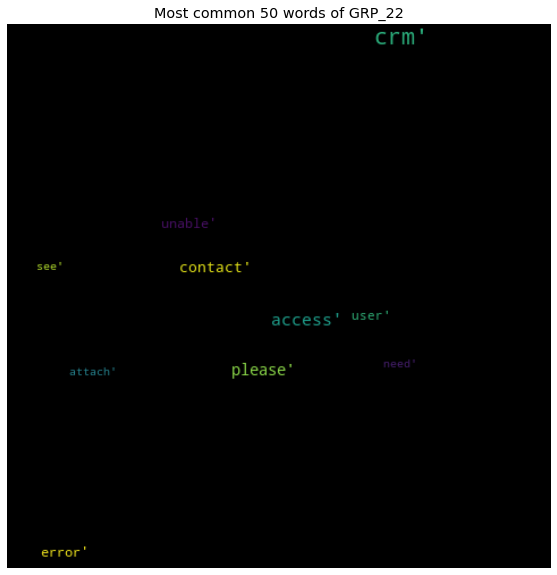

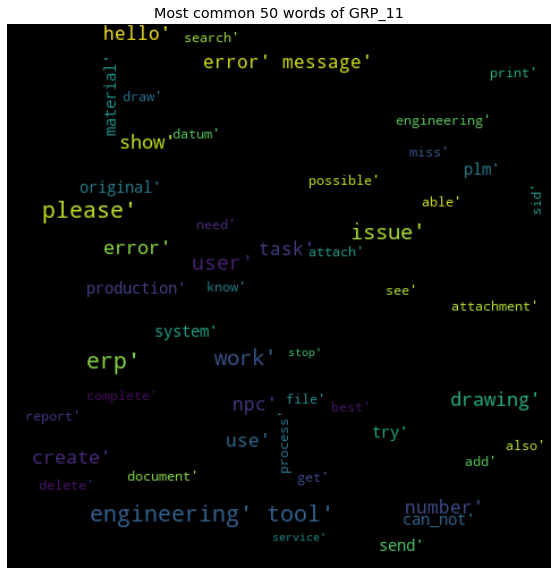

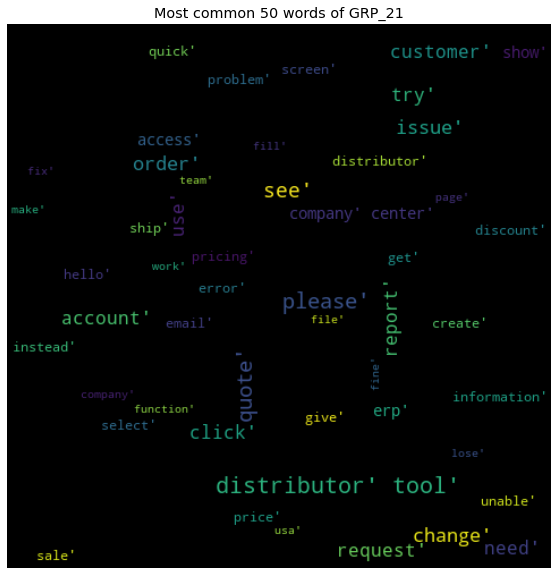

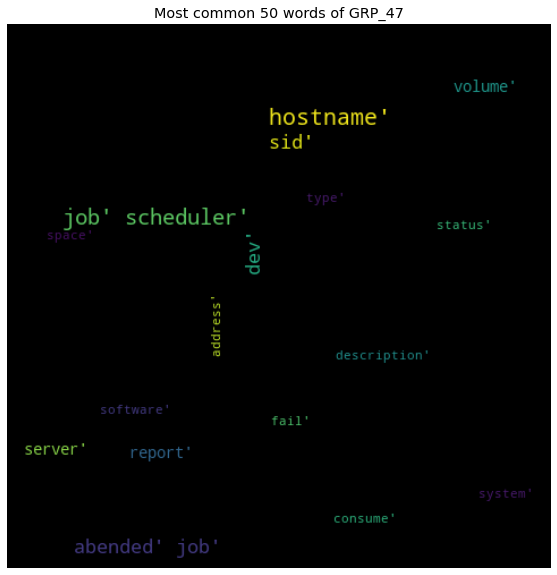

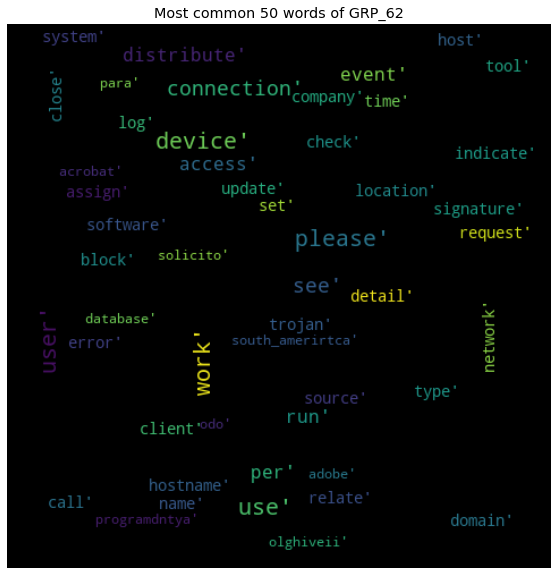

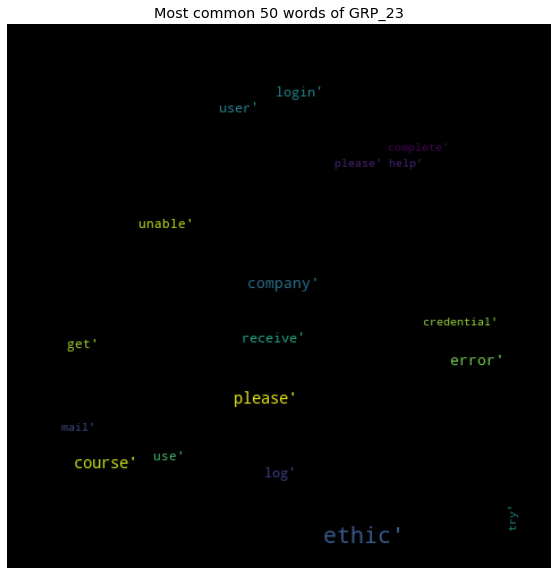

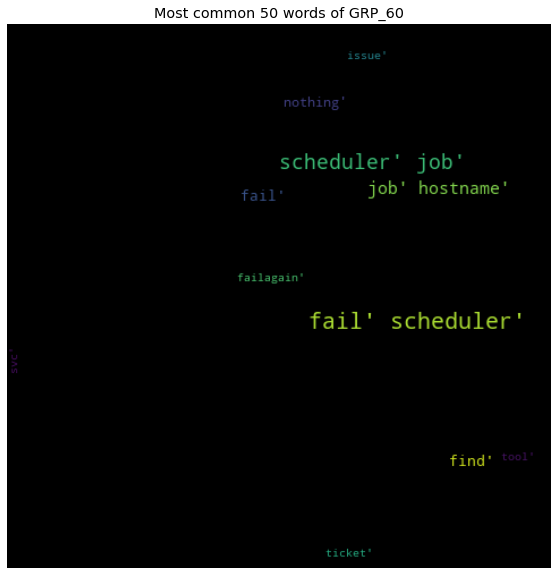

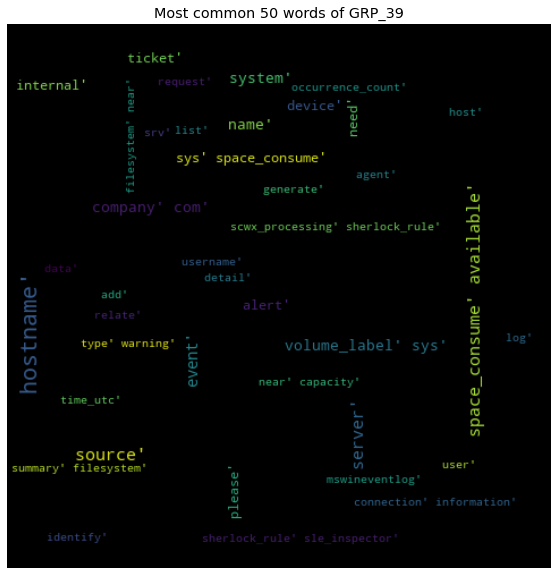

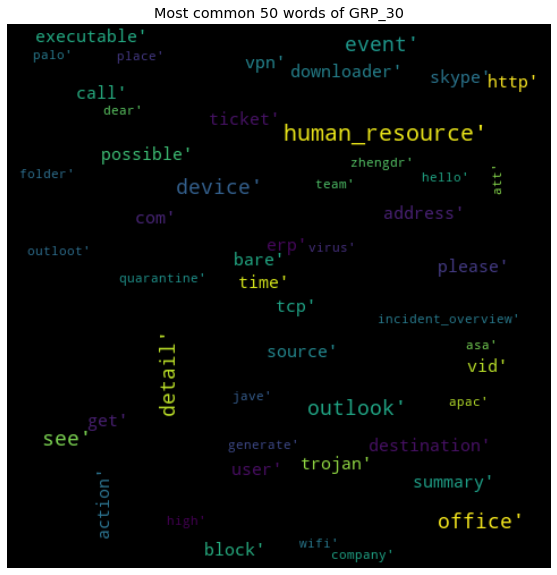

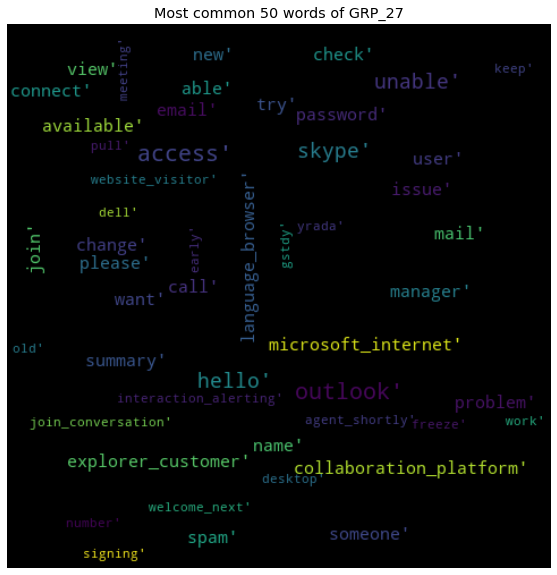

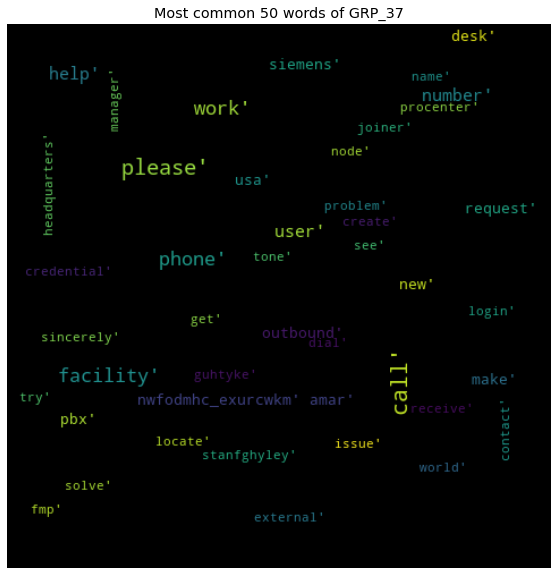

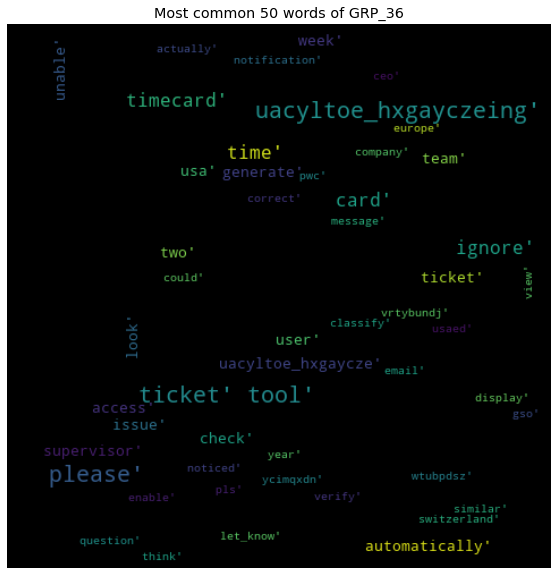

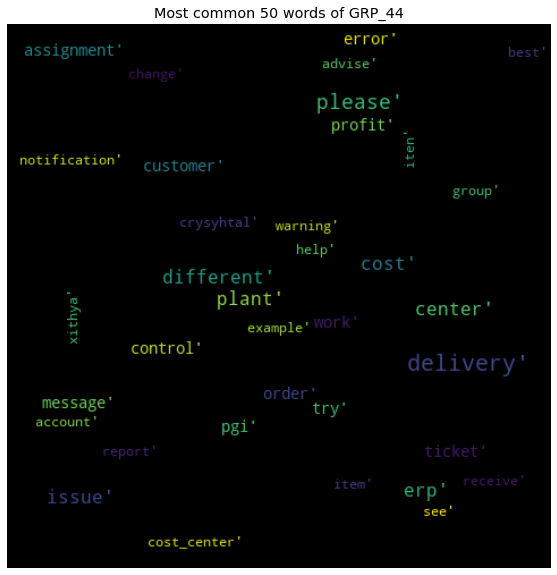

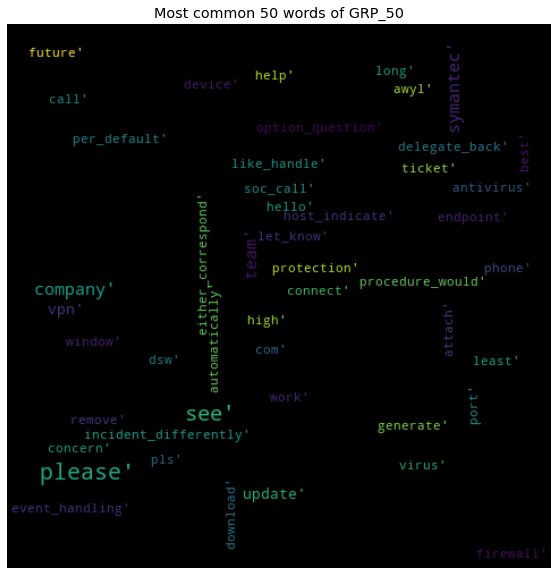

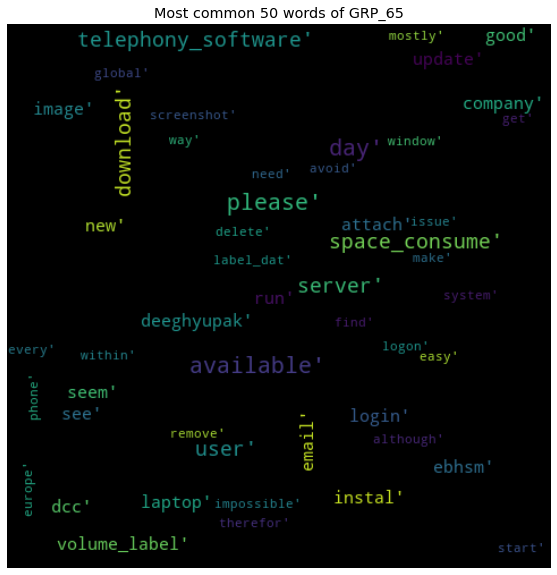

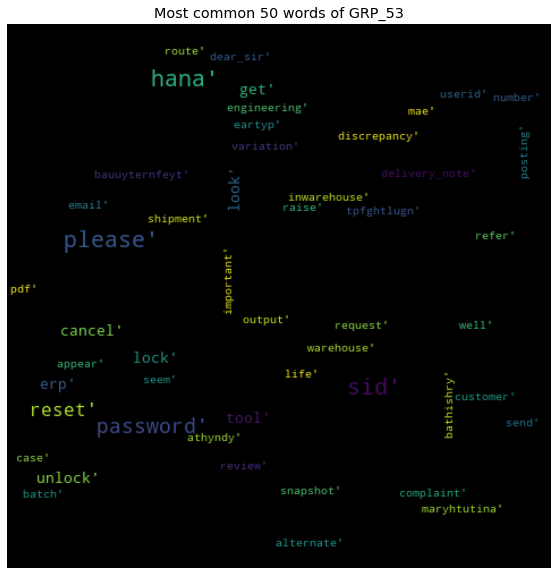

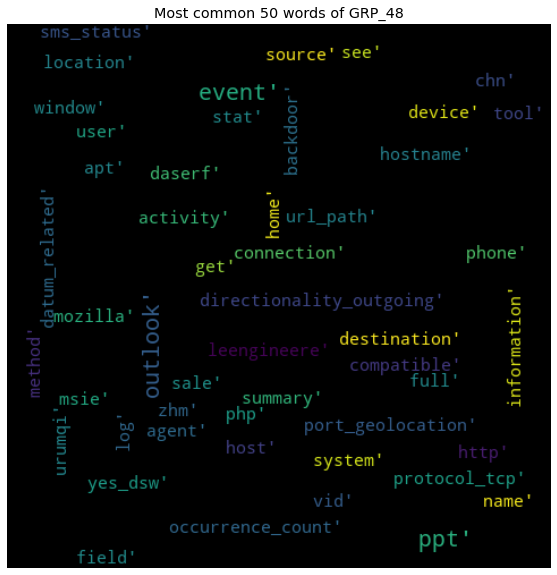

In [ ]:
#for loop to pass the top 50 Assignment groups

for i in range(50):

    Grp = new_df[new_df ['Assignment group'] == value[i]]
    Grp = Grp['words']
    wordcloud_grp(Grp,value[i])

In [0]:
# Create Dictionary
id2word = corpora.Dictionary(data_words_bigrams)

# Create Corpus from post clean data 
texts = data_words_bigrams

# Term Document Frequency and Bag of words 
#https://radimrehurek.com/gensim/corpora/dictionary.html
corpus = [id2word.doc2bow(text) for text in texts]

In [ ]:
# View not human readable 
print(corpus[:1])

[[(0, 1), (1, 1), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1)]]


In [ ]:
#possible human redable 
print([[(id2word[id], freq) for id, freq in cp] for cp in corpus[:1]])

[[('able', 1), ('advise', 1), ('caller_confirm', 1), ('check', 2), ('detail', 1), ('employee', 1), ('issue', 1), ('login', 1), ('manager', 1), ('name', 1), ('password', 1), ('reset', 1), ('resolve', 1), ('user', 1), ('verify', 1)]]


Bag of word model is working with bi gram and trigram model getting more insight from the words and its frequencey in document 1  . 


1.   Caller_confirmed occur once in document 1 
2.   check occur twice  in document 1 



In [0]:
# Build LDA model
#https://radimrehurek.com/gensim/models/ldamodel.html
lda_model = LdaModel(corpus=corpus,id2word=id2word,num_topics=7,random_state=200,update_every=1,chunksize=800,passes=10,alpha='auto',per_word_topics=True)

In [ ]:
#top 7 topics from the corpus 
from pprint import pprint
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.072*"job" + 0.068*"password" + 0.068*"scheduler" + 0.049*"account" + '
  '0.047*"fail" + 0.041*"reset" + 0.039*"sid" + 0.031*"erp" + 0.030*"abended" '
  '+ 0.026*"lock"'),
 (1,
  '0.042*"unable" + 0.016*"connect" + 0.015*"vpn" + 0.015*"login" + '
  '0.015*"email" + 0.014*"please" + 0.013*"outlook" + 0.012*"access" + '
  '0.011*"mail" + 0.011*"best"'),
 (2,
  '0.017*"access" + 0.016*"please" + 0.016*"connection" + 0.015*"hello" + '
  '0.012*"drive" + 0.011*"network" + 0.011*"company" + 0.010*"computer" + '
  '0.009*"friendly" + 0.007*"agent"'),
 (3,
  '0.023*"hostname" + 0.012*"call" + 0.011*"event" + 0.011*"com" + '
  '0.010*"device" + 0.010*"server" + 0.008*"company" + 0.007*"code" + '
  '0.006*"service" + 0.006*"see"'),
 (4,
  '0.030*"please" + 0.021*"issue" + 0.018*"error" + 0.017*"tool" + '
  '0.015*"user" + 0.013*"system" + 0.013*"work" + 0.013*"need" + 0.013*"get" + '
  '0.012*"ticket"'),
 (5,
  '0.032*"phone" + 0.031*"company" + 0.030*"email" + 0.025*"start" + '
  '0.0

In [ ]:
texts=data_words_bigrams
# Compute Perplexity
print('\nPerplexity: ', lda_model.log_perplexity(corpus))  # a measure of how good the model is. lower the better.

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)



Perplexity:  -7.325334506144987

Coherence Score:  0.5258151023526292


In [ ]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.127786  0.220161       1        1  40.185707
0     -0.326014 -0.156924       2        1  13.393537
1      0.033386  0.188831       3        1  12.098944
3      0.129041 -0.187311       4        1  10.926174
2      0.063540  0.081895       5        1   9.500206
6      0.164259 -0.010328       6        1   7.445634
5      0.063573 -0.136324       7        1   6.449796, topic_info=          Term        Freq        Total Category  logprob  loglift
165        job  893.000000   893.000000  Default  30.0000  30.0000
10    password  845.000000   845.000000  Default  29.0000  29.0000
189  scheduler  836.000000   836.000000  Default  28.0000  28.0000
94     account  601.000000   601.000000  Default  27.0000  27.0000
188       fail  579.000000   579.000000  Default  26.0000  26.0000
..         ...         ...          ...      ...      ...      ...
38     company  185.894073   641.275513   Topic7  -3.4650   1.5028
56      ticket  127.389046   590.570740   Topic7  -3.8430   1.2073
89        work  135.607056   676.693970   Topic7  -3.7805   1.1337
11       reset  116.943535   629.509888   Topic7  -3.9285   1.0579
23      please  148.208618  1657.990601   Topic7  -3.6916   0.3264

[384 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
8389      2  0.996939  abended
0         1  0.917385     able
0         3  0.075942     able
0         5  0.003038     able
31        1  0.552490   access
...     ...       ...      ...
179       4  0.047673  working
594       3  0.782835    would
594       5  0.213500    would
1194      5  0.969749    write
277       7  0.996928      yes

[508 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 1, 2, 4, 3, 7, 6])

# Provide info to business 

In [ ]:
# add a deep copy to another dataframe itTicketDF  to other DF
data =  itTicketDF.copy()
data['num_words'] = data.Description.apply(lambda x : len(x.split()))
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
length,8439.0,141.761228,312.312703,3.0,34.0,58.0,148.0,6190.0
num_words,8439.0,11.889086,18.599693,0.0,3.0,6.0,14.0,434.0


In [0]:
bins=[0,50,75, np.inf]
data['bins']=pd.cut(data.num_words, bins=[0,100,300,500,800, np.inf], labels=['0-100', '100-300', '300-500','500-800' ,'>800'])
word_distribution = data.groupby('bins').size().reset_index().rename(columns={0:'counts'})

In [ ]:
word_distribution

,bins,counts
0,0-100,8340
1,100-300,33
2,300-500,7
3,500-800,0
4,>800,0


Text(0.5, 1.0, 'Word distribution per bin')

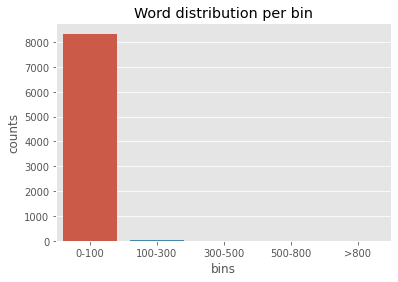

In [ ]:
sns.barplot(x='bins', y='counts', data=word_distribution).set_title("Word distribution per bin")

**Observation**
*   Most of the descrption of the problems raised by callers are short with in 0-100 words
*   Few items are with bit descriptive 



# Generate Dataset for createing 2 models
- Model 1 : Group 0 & all other groups combined to "other"
- Model 2 : Group 0 removed & only includes other groups
- Model 1 will be use dto classing group 0. If not found to be Group 0, we can classify using Model 2.

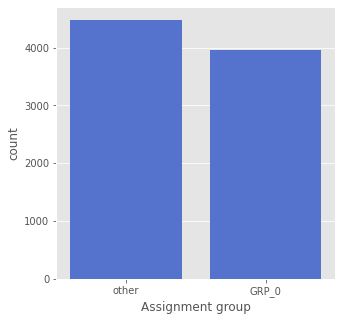

In [ ]:
# Create the Dataset for classifying GRP_0
itTicketGRP0DF = itTicketDF.copy()
itTicketGRP0DF['Assignment group']=itTicketGRP0DF['Assignment group'].apply(lambda x : 'other' if x != 'GRP_0'  else x)

descending_order = itTicketGRP0DF['Assignment group'].value_counts().sort_values(ascending=False).index
plt.subplots(figsize=(5,5))
sns.countplot(x='Assignment group', data=itTicketGRP0DF, color='royalblue',order=descending_order)

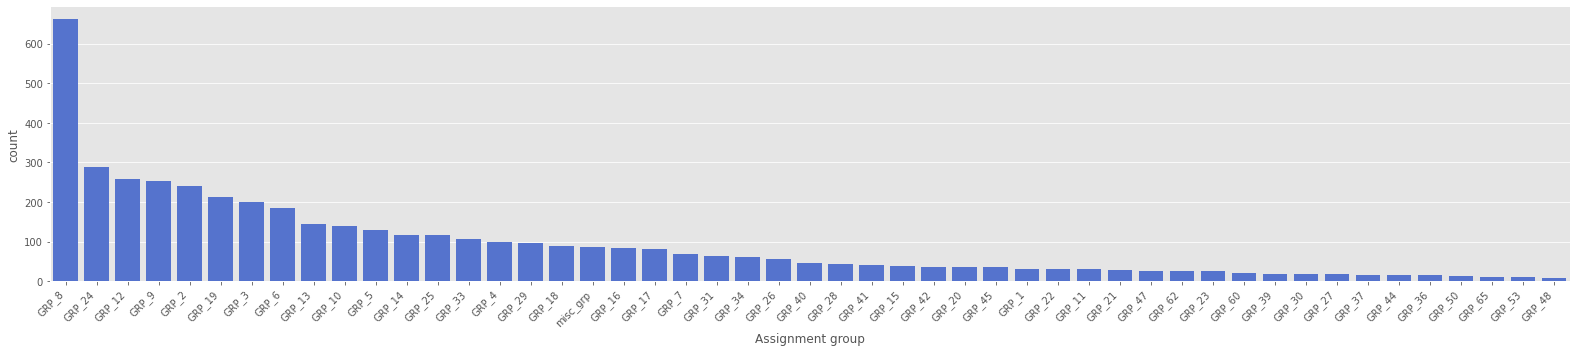

In [ ]:
#Create Dataset for 'others' i.e all groups which is not part of GRP_0
itTicketOthersDF = itTicketDF[itTicketDF['Assignment group'] != 'GRP_0']

descending_order = itTicketOthersDF['Assignment group'].value_counts().sort_values(ascending=False).index
plt.subplots(figsize=(22,5))
#add code to rotate the labels
ax=sns.countplot(x='Assignment group', data=itTicketOthersDF, color='royalblue',order=descending_order)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Observation
- There is high imbalance within the other group

In [ ]:
maxOthers = itTicketOthersDF['Assignment group'].value_counts().max()
maxOthers

661

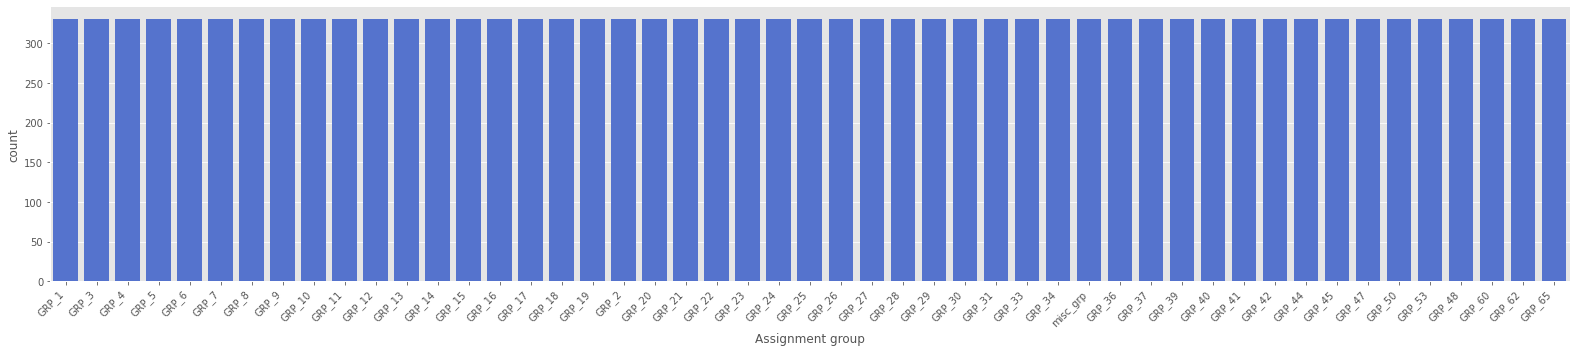

In [ ]:
# Treat the imbalnce in the 'other' dataset by resampling
from sklearn.utils import resample
itTicketOthersDF_resampled = itTicketOthersDF[0:0]
for grp in itTicketOthersDF['Assignment group'].unique():
    itTicketGrpDF = itTicketOthersDF[itTicketOthersDF['Assignment group'] == grp]
    resampled = resample(itTicketGrpDF, replace=True, n_samples=int(maxOthers/2), random_state=123)
    itTicketOthersDF_resampled = itTicketOthersDF_resampled.append(resampled)

otherGrpsResampled = pd.concat([itTicketGRP0DF,itTicketOthersDF_resampled])
otherGrpsResampled.reset_index(inplace=True)

descending_order = itTicketOthersDF_resampled['Assignment group'].value_counts().sort_values(ascending=False).index
plt.subplots(figsize=(22,5))
#add code to rotate the labels
ax=sns.countplot(x='Assignment group', data=itTicketOthersDF_resampled, color='royalblue')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

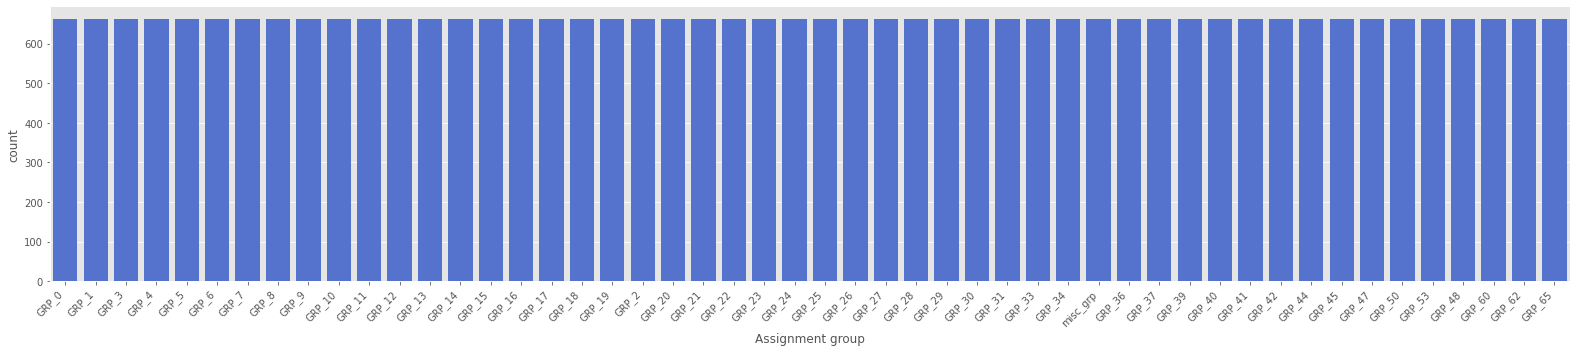

In [ ]:
# Treat the imbalnce in the itTicketDF dataset by resampling to 661.This is for us to try creating a single model which use the whiole dataset & verify the performance
itTicketDF_resampled = itTicketDF[0:0]
for grp in itTicketDF['Assignment group'].unique():
    itTicketGrpDF = itTicketDF[itTicketDF['Assignment group'] == grp]
    resampled = resample(itTicketGrpDF, replace=True, n_samples=int(maxOthers), random_state=123)
    itTicketDF_resampled = itTicketDF_resampled.append(resampled)

descending_order = itTicketDF_resampled['Assignment group'].value_counts().sort_values(ascending=False).index
plt.subplots(figsize=(22,5))
#add code to rotate the labels
ax=sns.countplot(x='Assignment group', data=itTicketDF_resampled, color='royalblue')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Label Encoding 'Assignment group' target class 


In [ ]:
from sklearn import preprocessing
def labelencoder(dataframe) : 
  label_encoder = preprocessing.LabelEncoder() 
  dataframe= label_encoder.fit_transform(dataframe)
  grp_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
  return dataframe,grp_mapping

#itTicketGRP0DF['Assignment group'] , grp_mapping_grp0= labelencoder(itTicketGRP0DF['Assignment group'])
#itTicketOthersDF_resampled['Assignment group'] , grp_mapping_others_resampled= labelencoder(itTicketOthersDF_resampled['Assignment group'])
otherGrpsResampled['Assignment group'] , grp_mapping_others_resampled= labelencoder(otherGrpsResampled['Assignment group'])
itTicketDF_resampled['Assignment group'] , grp_mapping_all_resampled= labelencoder(itTicketDF_resampled['Assignment group'])
itTicketDF['Assignment group'],grp_mapping_all_raw = labelencoder(itTicketDF['Assignment group'])

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


# Modelling

In [0]:
from gensim.models import Word2Vec
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation, Flatten, Bidirectional, GlobalMaxPool1D,GRU,Conv1D,MaxPooling1D
from tensorflow.keras.models import Model, Sequential
import tensorflow as tf
from sklearn import metrics
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [0]:
# Add Function to capture results from each model 
import operator
def captureData(dataframe,modelHistory,modelName,descriptions,index_df,resetData):
  if resetData == 1:
    tempResultsDf=pd.DataFrame()
    dataframe=pd.DataFrame()
  else:
    index, acc_value = max(enumerate(modelHistory.history['val_accuracy']), key=operator.itemgetter(1))
    tempResultsDf= pd.DataFrame(
      {'model':[modelName], 
      'val_accuracy': [acc_value],
      'val_loss':[modelHistory.history['val_loss'][index]],
      'loss':[modelHistory.history['loss'][index]],
      'accuracy':[modelHistory.history['accuracy'][index]],
      'descriptions':[descriptions]},index={str(index_df)})
    dataframe = pd.concat([dataframe,tempResultsDf])
    dataframe = dataframe[['model','val_accuracy' ,'val_loss','loss','accuracy','descriptions']] 
  return dataframe

def capturePrediction(dataframe,modelName,descriptions,index_df,pred_accuracy,resetData):
  if resetData == 1:
    tempResultsDf=pd.DataFrame()
    dataframe=pd.DataFrame()
  else:
    tempResultsDf= pd.DataFrame(
      {'model':[modelName], 
      'Pred_Accuracy' : [pred_accuracy],
      'descriptions':[descriptions]},index={str(index_df)})
    dataframe = pd.concat([dataframe,tempResultsDf])
    dataframe = dataframe[['model','Pred_Accuracy','descriptions']] 
  return dataframe


## Word2Vec embedding 

In [ ]:
sentences = [line.split(' ') for line in itTicketDF['Description']]
word2vec = Word2Vec(sentences=sentences,min_count=1)
word2vec.wv.save_word2vec_format(project_path+ 'word2vec_vector.txt')

/usr/local/lib/python3.6/dist-packages/smart_open/smart_open_lib.py:253: UserWarning: This function is deprecated, use smart_open.open instead. See the migration notes for details: https://github.com/RaRe-Technologies/smart_open/blob/master/README.rst#migrating-to-the-new-open-function
  'See the migration notes for details: %s' % _MIGRATION_NOTES_URL


In [ ]:
# load the whole embedding into memory
embeddings_index = dict()
f = open(project_path+'word2vec_vector.txt')

for line in f:
	values = line.split()
	word = values[0]
	coefs = np.asarray(values[1:], dtype='float32')
	embeddings_index[word] = coefs
f.close()
print('Loaded %s word vectors.' % len(embeddings_index))


Loaded 9463 word vectors.


In [0]:
maxlen = 300
numWords=9000
epochs = 10

In [0]:
results=pd.DataFrame()
pred_results = pd.DataFrame()

### LSTM Model

In [0]:
class LstmModel:
  model= Model()
  X_test=[]
  y_test=[]
  embedding_matrix=[]

  def wordTokenizer(self, dataframe):
    tokenizer = Tokenizer(num_words=numWords,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True,split=' ', char_level=False)
    tokenizer.fit_on_texts(dataframe)
    dataframe = tokenizer.texts_to_sequences(dataframe)
    return tokenizer,dataframe
  
  def splitData(self,X,y):

    print("Number of Samples:", len(X))
    print("Number of Labels: ", len(y))
    X_train, self.X_test, y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=10) # changed by Abraham
    X_train, X_Val, y_train, y_Val = train_test_split(X, y, test_size=0.2, random_state=10)
    print("Number of train Samples:", len(X_train))
    print("Number of val Samples:", len(X_Val))

    return X_train, self.X_test, y_train, self.y_test, X_Val, y_Val

  def tokenizeAndEmbedding(self,dataframe):
    
    tokenizer,X = self.wordTokenizer(dataframe['Description'])
    y = np.asarray(dataframe['Assignment group'])
    X = pad_sequences(X, maxlen = maxlen)

    self.embedding_matrix = np.zeros((numWords+1, 100))
    for i,word in tokenizer.index_word.items():
      if i<numWords+1:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            self.embedding_matrix[i] = embedding_vector
    return X,y

  def train(self, dataframe, batch_size, epochs):
   
    X,y = self.tokenizeAndEmbedding(dataframe)
    X_train, _, y_train, _, X_Val, y_Val = self.splitData(X,y)
    model_history = self.fitModel(X_train,y_train,X_Val,y_Val,batch_size, epochs)
    return model_history

  def fitModel(self,X_train,y_train,X_Val,y_Val,batch_size, epochs):
    
    input_layer = Input(shape=(maxlen,),dtype=tf.int64)
    embed = Embedding(numWords+1,output_dim=100,input_length=maxlen,weights=[self.embedding_matrix], trainable=True)(input_layer)  #weights=[embedding_matrix]
    lstm=Bidirectional(LSTM(128))(embed)
    drop=Dropout(0.3)(lstm)
    dense =Dense(100,activation='relu')(drop)
    out=Dense(len((pd.Series(y_train)).unique()),activation='softmax')(dense)   

    self.model = Model(input_layer,out)
    self.model.compile(loss='sparse_categorical_crossentropy',optimizer="adam",metrics=['accuracy'])

    self.model.summary()
    plot_model(self.model,to_file="LSTM_Model.jpg")

    checkpoint = ModelCheckpoint('model-{epoch:03d}-{val_accuracy:03f}.h5', verbose=1, monitor='val_accuracy',save_best_only=True, mode='auto') 
    reduceLoss = ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=2, min_lr=0.0001)
    model_history = self.model.fit(X_train,y_train,batch_size=batch_size, epochs=epochs, callbacks=[checkpoint,reduceLoss], validation_data=(X_Val,y_Val))

    return model_history,self.model

  def prediction(self):
      
     pred = self.model.predict(self.X_test)
     pred = [i.argmax() for i in pred]
     accuracy = metrics.accuracy_score(self.y_test, pred)
     print("Accuracy of the model :",metrics.accuracy_score(self.y_test, pred))
     return accuracy

  def plotModelAccuracy(self, history, modelname):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(modelname+' model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(modelname+' model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

In [ ]:
# Check how the LSTM Model perform with the cleansed data
lstmModelRawData = LstmModel()
lstmModelRawData_history, model = lstmModelRawData.train(itTicketDF,100,epochs)
rawData_accuracy = lstmModelRawData.prediction()

Number of Samples: 8439
Number of Labels:  8439
Number of train Samples: 6751
Number of val Samples: 1688
Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 300)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 300, 100)          900100    
_________________________________________________________________
bidirectional (Bidirectional (None, 256)               234496    
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
dense (Dense)                (None, 100)               25700     
_________________________________________________________________
dense_1 (Dense)              (None, 50)                5050      
Total params: 1,165

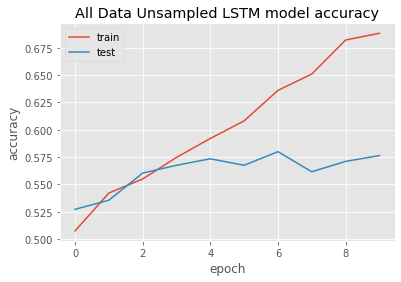

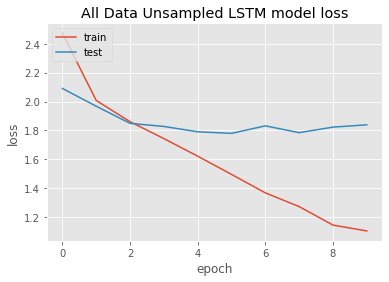

In [ ]:
lstmModelRawData.plotModelAccuracy(lstmModelRawData_history, 'All Data Unsampled LSTM')

In [ ]:
# Check how the LSTM Model perform with all the data which is cleansed & resampled to 661 to make the target balance
lstmModelAllDataResampled = LstmModel()
lstmModelAllDataResampled_history, model = lstmModelAllDataResampled.train(itTicketDF_resampled,100,epochs)
resampled_accuracy = lstmModelAllDataResampled.prediction()


Number of Samples: 33050
Number of Labels:  33050
Number of train Samples: 26440
Number of val Samples: 6610
Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 300)]             0         
_________________________________________________________________
embedding_1 (Embedding)      (None, 300, 100)          900100    
_________________________________________________________________
bidirectional_1 (Bidirection (None, 256)               234496    
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 100)               25700     
_________________________________________________________________
dense_3 (Dense)              (None, 50)                5050      
Total params: 1,

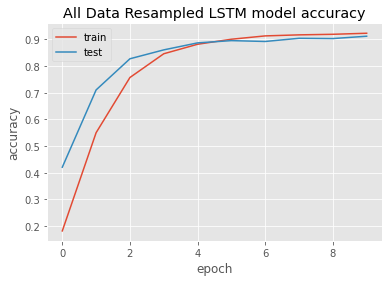

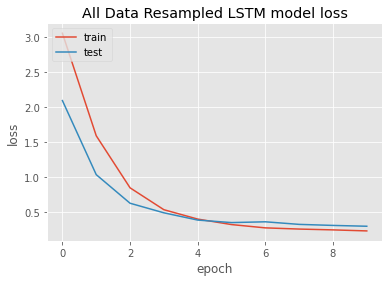

In [ ]:
lstmModelAllDataResampled.plotModelAccuracy(lstmModelAllDataResampled_history, 'All Data Resampled LSTM')

#### Dataframe result capture

In [0]:
results=pd.DataFrame()
pred_results = pd.DataFrame()
results=captureData(results,lstmModelRawData_history,'LSTM model_WV_rawdata','LSTM+Word2Vec Embedding on raw data','1',0)
pred_results= capturePrediction(pred_results,'LSTM model_WV_rawdata','LSTM+Word2Vec Embedding on raw data','1',rawData_accuracy,0)

In [0]:
results=captureData(results,lstmModelAllDataResampled_history,'LSTM model_WV_resampled data','LSTM+Word2Vec Embedding on Augmented data','2',0)
pred_results= capturePrediction(pred_results,'LSTM model_WV_resampled data','LSTM+Word2Vec Embedding on Augmented data','2',resampled_accuracy,0)

### LSTM two part model

In [0]:
class TwoModel:

  model_1 = Model()
  model_2 = Model()
  embedding_matrix=[]

  def wordTokenizer(self, dataframe):
    tokenizer = Tokenizer(num_words=numWords,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True,split=' ', char_level=False)
    tokenizer.fit_on_texts(dataframe)
    dataframe = tokenizer.texts_to_sequences(dataframe)

    self.embedding_matrix = np.zeros((numWords+1, 100))
    for i,word in tokenizer.index_word.items():
      if i<numWords+1:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            self.embedding_matrix[i] = embedding_vector
    return tokenizer,dataframe

  def splitData(self,X,y):

    print("Number of Samples:", len(X))
    print("Number of Labels: ", len(y))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10) # changed by Abraham
    X_train, X_Val, y_train, y_Val = train_test_split(X, y, test_size=0.2, random_state=10)
    print("Number of train Samples:", len(X_train))
    print("Number of val Samples:", len(X_Val))

    return X_train, X_test, y_train, y_test, X_Val, y_Val

  def runFirstModel(self,dataframe,epochs):

    grp0_df = dataframe.copy()
    grp0_df['Assignment group']=dataframe['Assignment group'].apply(lambda x : 1 if x != 0  else x)
    tokenizer,X = self.wordTokenizer(grp0_df['Description'])
    y = np.asarray(grp0_df['Assignment group'])
    X = pad_sequences(X, maxlen = maxlen)
    X_train, _, y_train, _, X_Val, y_Val = self.splitData(X,y)

    model_history,self.model_1 = self.modelRunner(X_train,y_train,X_Val,y_Val,epochs)
    return model_history,self.model_1

  def runSecondModel(self, dataframe,epochs):

    grpOthers_df = dataframe.copy()
    grpOthers_df = grpOthers_df[grpOthers_df['Assignment group'] != 0]
    grpOthers_df['Assignment group']=grpOthers_df['Assignment group'] - 1
    tokenizer,X = self.wordTokenizer(grpOthers_df['Description'])
    y = np.asarray(grpOthers_df['Assignment group'])
    X = pad_sequences(X, maxlen = maxlen)
    X_train, _, y_train, _, X_Val, y_Val = self.splitData(X,y)
      
    model_history,self.model_2 = self.modelRunner(X_train,y_train,X_Val,y_Val,epochs)
    return model_history,self.model_2

  def modelRunner(self, X,Y,X_Val,Y_Val,epochs):
        
        input_layer = Input(shape=(maxlen,),dtype=tf.int64)
        embed = Embedding(input_dim = numWords+1,output_dim=100,input_length=maxlen,weights=[self.embedding_matrix], trainable=True)(input_layer)  #
        lstm=Bidirectional(LSTM(128))(embed)
        drop=Dropout(0.3)(lstm)
        dense =Dense(100,activation='relu')(drop)
        out=Dense(len((pd.Series(Y)).unique()),activation='softmax')(dense)   
        batch_size = 100
        
        model = Model(input_layer,out)
        model.compile(loss='sparse_categorical_crossentropy',optimizer="adam",metrics=['accuracy'])
        
        checkpoint = ModelCheckpoint('model-{epoch:03d}-{val_accuracy:03f}.h5', verbose=1, monitor='val_accuracy',save_best_only=True, mode='auto') 
        reduceLoss = ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=2, min_lr=0.0001)
        
        model_history = model.fit(X,Y,batch_size=batch_size, epochs=epochs, callbacks=[checkpoint,reduceLoss], validation_data=(X_Val,Y_Val))
        return model_history,model

  def predict(self, X_test):
        predBinary = self.model_1.predict(X_test)
        predBinary = [1 if j>i else 0 for i,j in predBinary]

        new_X_test = pd.DataFrame(X_test)
        new_X_test['grp']=predBinary
        sec_input = new_X_test[new_X_test['grp']!=0]
        sec_input.drop(['grp'],inplace=True, axis=1)
        new_X_test=new_X_test[new_X_test['grp']==0]

        predOther = self.model_2.predict(sec_input)
        predOther = [i.argmax() for i in predOther]
        predOther= [i+1 for i in predOther]
        sec_input['grp']=predOther

        pred_df = pd.concat([new_X_test,sec_input])
        pred_df.sort_index(axis=0,inplace=True)

        return np.array(pred_df['grp'])

  def plotModelAccuracy(self, history, modelname):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(modelname+' model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(modelname+' model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()


In [ ]:
model = TwoModel()
model1_history,_ = model.runFirstModel(otherGrpsResampled,5)
model2_history,_ = model.runSecondModel(otherGrpsResampled,20)

tokenizer,X = model.wordTokenizer(otherGrpsResampled['Description'])
y = np.asarray(otherGrpsResampled['Assignment group'])
X = pad_sequences(X, maxlen = maxlen)
_, X_test, _, y_test, _, _ = model.splitData(X,y)

predictions = model.predict(X_test)
twoModel_sampledAccuracy = metrics.accuracy_score(y_test, predictions)
print("Accuracy:",twoModel_sampledAccuracy)

Number of Samples: 24609
Number of Labels:  24609
Number of train Samples: 19687
Number of val Samples: 4922
Epoch 1/5
197/197 [==============================] - ETA: 0s - loss: 0.3320 - accuracy: 0.8684
Epoch 00001: val_accuracy improved from -inf to 0.88663, saving model to model-001-0.886631.h5
197/197 [==============================] - 373s 2s/step - loss: 0.3320 - accuracy: 0.8684 - val_loss: 0.2677 - val_accuracy: 0.8866 - lr: 0.0010
Epoch 2/5
197/197 [==============================] - ETA: 0s - loss: 0.2052 - accuracy: 0.9158
Epoch 00002: val_accuracy improved from 0.88663 to 0.91690, saving model to model-002-0.916904.h5
197/197 [==============================] - 368s 2s/step - loss: 0.2052 - accuracy: 0.9158 - val_loss: 0.2078 - val_accuracy: 0.9169 - lr: 0.0010
Epoch 3/5
197/197 [==============================] - ETA: 0s - loss: 0.1236 - accuracy: 0.9520
Epoch 00003: val_accuracy improved from 0.91690 to 0.93316, saving model to model-003-0.933157.h5
197/197 [================

/usr/local/lib/python3.6/dist-packages/pandas/core/frame.py:3997: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


Accuracy: 0.27813896789922793


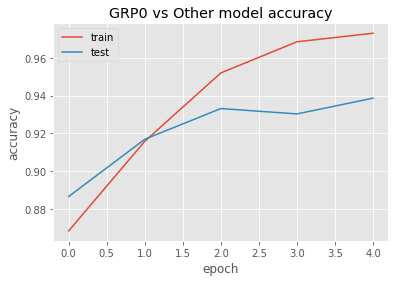

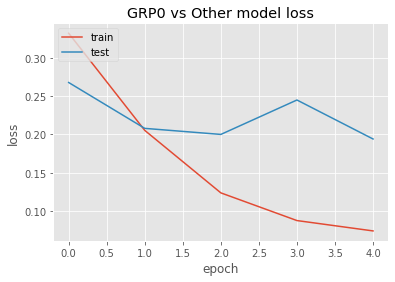

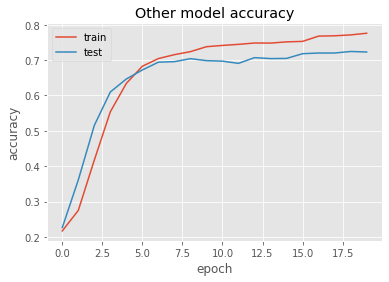

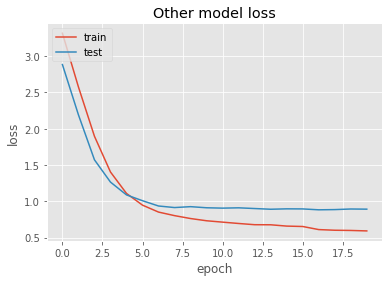

In [ ]:
model.plotModelAccuracy(model1_history, 'GRP0 vs Other')
model.plotModelAccuracy(model2_history, 'Other')

#### Dataframe result capture

In [0]:
results=captureData(results,model1_history,'LSTM 2 part model_WV_grp0','LSTM+Word2Vec Embedding on grp0_data','3',0)
results=captureData(results,model2_history,'LSTM 2 part model_WV_Others','LSTM+Word2Vec Embedding on Rest of groups','4',0)
pred_results= capturePrediction(pred_results,'LSTM 2 part model_WV','LSTM+Word2Vec Embedding on Augmented data','3',twoModel_sampledAccuracy,0)

## Glove embedding

In [ ]:
#download the glove embedding from https://nlp.stanford.edu/projects/glove/
#glove_file = "/content/drive/My Drive/ML_Project/NLP/NLP-1 Sentiment Classification/" + "glove.6B.zip"
glove_file = project_path + "glove.6B.zip"
print(glove_file)

/content/drive/My Drive/Capstone_NLP/glove.6B.zip


In [0]:
#Extract Glove embedding zip file
from zipfile import ZipFile
with ZipFile(glove_file, 'r') as z:
  z.extractall()

In [0]:
# EMBEDDING_FILE = './glove.6B.200d.txt'
EMBEDDING_FILE = './glove.6B.100d.txt'
embeddings_glove = {}
for o in open(EMBEDDING_FILE):
    word = o.split(" ")[0]
    #print(word)
    embd = o.split(" ")[1:]
    embd = np.asarray(embd, dtype='float32')
    #print(embd)
    embeddings_glove[word] = embd

In [ ]:
print("Dimension of the embedding vector is {}".format(len(embeddings_glove["collaboration"])))
print("Dimension of the embedding vector is {}".format(len(embeddings_glove["platform"])))

Dimension of the embedding vector is 100
Dimension of the embedding vector is 100


In [0]:
maxlen = 300
numWords=9000
epochs = 10

### LSTM Model

In [0]:
class LstmGloveModel:
  model= Model()
  X_test=[]
  y_test=[]
  embedding_matrix=[]

  def wordTokenizer(self, dataframe):
    tokenizer = Tokenizer(num_words=numWords,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True,split=' ', char_level=False)
    tokenizer.fit_on_texts(dataframe)
    dataframe = tokenizer.texts_to_sequences(dataframe)
    return tokenizer,dataframe
  
  def splitData(self,X,y):

    print("Number of Samples:", len(X))
    print("Number of Labels: ", len(y))
    X_train, self.X_test, y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=10) # changed by Abraham
    X_train, X_Val, y_train, y_Val = train_test_split(X, y, test_size=0.2, random_state=10)
    print("Number of train Samples:", len(X_train))
    print("Number of val Samples:", len(X_Val))

    return X_train, self.X_test, y_train, self.y_test, X_Val, y_Val

  def tokenizeAndEmbedding(self,dataframe):
    
    tokenizer,X = self.wordTokenizer(dataframe['Description'])
    y = np.asarray(dataframe['Assignment group'])
    X = pad_sequences(X, maxlen = maxlen)

    self.embedding_matrix = np.zeros((numWords+1, 100))
    for i,word in tokenizer.index_word.items():
      if i<numWords+1:
        embedding_vector = embeddings_glove.get(word)
        if embedding_vector is not None:
            self.embedding_matrix[i] = embedding_vector
    return X,y

  def train(self, dataframe, batch_size, epochs):
   
    X,y = self.tokenizeAndEmbedding(dataframe)
    X_train, _, y_train, _, X_Val, y_Val = self.splitData(X,y)
    model_history = self.fitModel(X_train,y_train,X_Val,y_Val,batch_size, epochs)
    return model_history

  def fitModel(self,X_train,y_train,X_Val,y_Val,batch_size, epochs):
    
    input_layer = Input(shape=(maxlen,),dtype=tf.int64)
    embed = Embedding(numWords+1,output_dim=100,input_length=maxlen,weights=[self.embedding_matrix], trainable=True)(input_layer)  #weights=[embedding_matrix]
    lstm=Bidirectional(LSTM(128))(embed)
    drop=Dropout(0.3)(lstm)
    dense =Dense(100,activation='relu')(drop)
    out=Dense(len((pd.Series(y_train)).unique()),activation='softmax')(dense)   

    self.model = Model(input_layer,out)
    self.model.compile(loss='sparse_categorical_crossentropy',optimizer="adam",metrics=['accuracy'])

    checkpoint = ModelCheckpoint('model-{epoch:03d}-{val_accuracy:03f}.h5', verbose=1, monitor='val_accuracy',save_best_only=True, mode='auto') 
    reduceLoss = ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=2, min_lr=0.0001)
    model_history = self.model.fit(X_train,y_train,batch_size=batch_size, epochs=epochs, callbacks=[checkpoint,reduceLoss], validation_data=(X_Val,y_Val))
    return model_history,self.model

  def prediction(self):
      
     pred = self.model.predict(self.X_test)
     pred = [i.argmax() for i in pred]
     accuracy = metrics.accuracy_score(self.y_test, pred)
     print("Accuracy of the model :",accuracy)
     return accuracy

  def plotModelAccuracy(self, history, modelname):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(modelname+' model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(modelname+' model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

In [ ]:
# Check how the LSTM Model perform with the cleansed data
# Check how the LSTM Model perform with the cleansed data
lstmModelRawData = LstmGloveModel()
lstmModelRawData_history, model = lstmModelRawData.train(itTicketDF,100,epochs)
lstm_raw_accuracy = lstmModelRawData.prediction()

Number of Samples: 8439
Number of Labels:  8439
Number of train Samples: 6751
Number of val Samples: 1688
Epoch 1/10
68/68 [==============================] - ETA: 0s - loss: 2.5581 - accuracy: 0.4835
Epoch 00001: val_accuracy improved from -inf to 0.52784, saving model to model-001-0.527844.h5
68/68 [==============================] - 124s 2s/step - loss: 2.5581 - accuracy: 0.4835 - val_loss: 2.1102 - val_accuracy: 0.5278 - lr: 0.0010
Epoch 2/10
68/68 [==============================] - ETA: 0s - loss: 1.9681 - accuracy: 0.5466
Epoch 00002: val_accuracy improved from 0.52784 to 0.56339, saving model to model-002-0.563389.h5
68/68 [==============================] - 123s 2s/step - loss: 1.9681 - accuracy: 0.5466 - val_loss: 1.9042 - val_accuracy: 0.5634 - lr: 0.0010
Epoch 3/10
68/68 [==============================] - ETA: 0s - loss: 1.7513 - accuracy: 0.5750
Epoch 00003: val_accuracy improved from 0.56339 to 0.56754, saving model to model-003-0.567536.h5
68/68 [============================

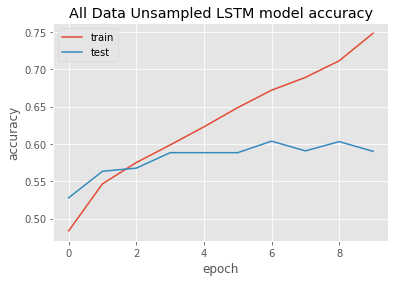

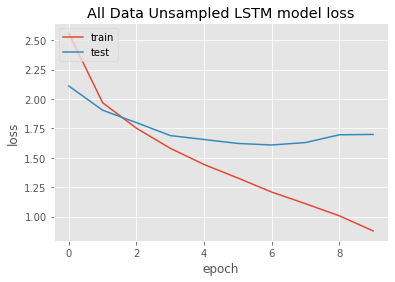

In [ ]:
lstmModelRawData.plotModelAccuracy(lstmModelRawData_history, 'All Data Unsampled LSTM')

In [ ]:
#Check how the LSTM Model perform with all the data which is cleansed & resampled to 661 to make the target balance
lstmModelAllDataResampled = LstmGloveModel()
lstmModelAllDataResampled_history, model = lstmModelAllDataResampled.train(itTicketDF_resampled,100,epochs)
lstm_allResampled_accuracy = lstmModelAllDataResampled.prediction()

Number of Samples: 33050
Number of Labels:  33050
Number of train Samples: 26440
Number of val Samples: 6610
Epoch 1/10
265/265 [==============================] - ETA: 0s - loss: 2.5982 - accuracy: 0.3193
Epoch 00001: val_accuracy improved from -inf to 0.62209, saving model to model-001-0.622088.h5
265/265 [==============================] - 495s 2s/step - loss: 2.5982 - accuracy: 0.3193 - val_loss: 1.3839 - val_accuracy: 0.6221 - lr: 0.0010
Epoch 2/10
265/265 [==============================] - ETA: 0s - loss: 1.0567 - accuracy: 0.7092
Epoch 00002: val_accuracy improved from 0.62209 to 0.79198, saving model to model-002-0.791982.h5
265/265 [==============================] - 494s 2s/step - loss: 1.0567 - accuracy: 0.7092 - val_loss: 0.7536 - val_accuracy: 0.7920 - lr: 0.0010
Epoch 3/10
265/265 [==============================] - ETA: 0s - loss: 0.6169 - accuracy: 0.8224
Epoch 00003: val_accuracy improved from 0.79198 to 0.85930, saving model to model-003-0.859304.h5
265/265 [=============

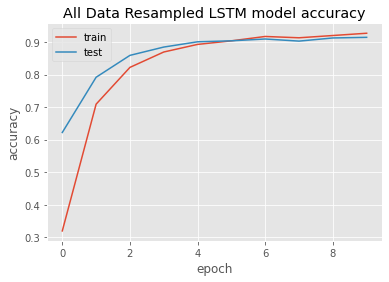

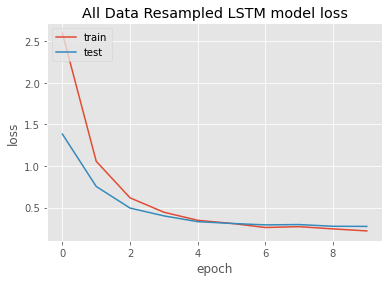

In [ ]:
lstmModelAllDataResampled.plotModelAccuracy(lstmModelAllDataResampled_history, 'All Data Resampled LSTM')

#### Dataframe result capture

In [0]:
results=captureData(results,lstmModelRawData_history,'LSTM model_GloVe_rawdata','LSTM+GloVe Embedding on raw data','5',0)
pred_results= capturePrediction(pred_results,'LSTM model_GloVe_rawdata','LSTM+GloVe Embedding on raw data','4',lstm_raw_accuracy,0)

In [0]:
results=captureData(results,lstmModelAllDataResampled_history,'LSTM model_GloVe_resampled data','LSTM+GloVe Embedding on Augmented data','6',0)
pred_results= capturePrediction(pred_results,'LSTM model_GloVe_resampled data','LSTM+GloVe Embedding on Augmented data','5',lstm_allResampled_accuracy,0)

### GRU Model

In [0]:
class GruGloveModel:
  model= Model()
  X_test=[]
  y_test=[]
  embedding_matrix=[]

  def wordTokenizer(self, dataframe):
    tokenizer = Tokenizer(num_words=numWords,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True,split=' ', char_level=False)
    tokenizer.fit_on_texts(dataframe)
    dataframe = tokenizer.texts_to_sequences(dataframe)
    return tokenizer,dataframe
  
  def splitData(self,X,y):

    print("Number of Samples:", len(X))
    print("Number of Labels: ", len(y))
    X_train, self.X_test, y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=10) # changed by Abraham
    X_train, X_Val, y_train, y_Val = train_test_split(X, y, test_size=0.2, random_state=10)
    print("Number of train Samples:", len(X_train))
    print("Number of val Samples:", len(X_Val))

    return X_train, self.X_test, y_train, self.y_test, X_Val, y_Val

  def tokenizeAndEmbedding(self,dataframe):
    
    tokenizer,X = self.wordTokenizer(dataframe['Description'])
    y = np.asarray(dataframe['Assignment group'])
    X = pad_sequences(X, maxlen = maxlen)

    self.embedding_matrix = np.zeros((numWords+1, 100))
    for i,word in tokenizer.index_word.items():
      if i<numWords+1:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            self.embedding_matrix[i] = embedding_vector
    return X,y

  def train(self, dataframe, batch_size, epochs):
   
    X,y = self.tokenizeAndEmbedding(dataframe)
    X_train, _, y_train, _, X_Val, y_Val = self.splitData(X,y)
    model_history = self.fitModel(X_train,y_train,X_Val,y_Val,batch_size, epochs)
    return model_history

  def fitModel(self,X_train,y_train,X_Val,y_Val,batch_size, epochs):
    
    input_layer = Input(shape=(maxlen,),dtype=tf.int64)
    embed = Embedding(numWords+1,output_dim=100,input_length=maxlen,weights=[self.embedding_matrix], trainable=True)(input_layer)  #weights=[embedding_matrix]
    gru=GRU(128)(embed)
    drop=Dropout(0.3)(gru)
    dense =Dense(100,activation='relu')(drop)
    out=Dense(len((pd.Series(y_train)).unique()),activation='softmax')(dense)   

    self.model = Model(input_layer,out)
    self.model.compile(loss='sparse_categorical_crossentropy',optimizer="adam",metrics=['accuracy'])

    # self.model.summary()
    # plot_model(self.model,to_file="GRU.jpg")

    checkpoint = ModelCheckpoint('model-{epoch:03d}-{val_accuracy:03f}.h5', verbose=1, monitor='val_accuracy',save_best_only=True, mode='auto') 
    reduceLoss = ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=2, min_lr=0.0001)
    model_history = self.model.fit(X_train,y_train,batch_size=batch_size, epochs=epochs, callbacks=[checkpoint,reduceLoss], validation_data=(X_Val,y_Val))
    return model_history,self.model

  def prediction(self):
      
     pred = self.model.predict(self.X_test)
     pred = [i.argmax() for i in pred]
     accuracy=metrics.accuracy_score(self.y_test, pred)
     print("Accuracy of the model :",accuracy)
     return accuracy

  def plotModelAccuracy(self, history, modelname):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(modelname+' model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(modelname+' model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

  def plotModel(self):
    self.model.summary()

In [ ]:
# Check how the GRU Model perform with the cleansed data
# Check how the LSTM Model perform with the cleansed data
gruModelRawData = GruGloveModel()
gruModelRawData_history, model = gruModelRawData.train(itTicketDF,100,epochs)
gruRaw_accuracy = gruModelRawData.prediction()

Number of Samples: 8439
Number of Labels:  8439
Number of train Samples: 6751
Number of val Samples: 1688
Epoch 1/10
68/68 [==============================] - ETA: 0s - loss: 2.5058 - accuracy: 0.4974
Epoch 00001: val_accuracy improved from -inf to 0.52784, saving model to model-001-0.527844.h5
68/68 [==============================] - 52s 763ms/step - loss: 2.5058 - accuracy: 0.4974 - val_loss: 2.1237 - val_accuracy: 0.5278 - lr: 0.0010
Epoch 2/10
68/68 [==============================] - ETA: 0s - loss: 2.0482 - accuracy: 0.5410
Epoch 00002: val_accuracy improved from 0.52784 to 0.53614, saving model to model-002-0.536137.h5
68/68 [==============================] - 52s 759ms/step - loss: 2.0482 - accuracy: 0.5410 - val_loss: 1.9495 - val_accuracy: 0.5361 - lr: 0.0010
Epoch 3/10
68/68 [==============================] - ETA: 0s - loss: 1.8435 - accuracy: 0.5570
Epoch 00003: val_accuracy improved from 0.53614 to 0.56398, saving model to model-003-0.563981.h5
68/68 [========================

In [ ]:
gruModelRawData.plotModel()

Model: "model_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_7 (InputLayer)         [(None, 300)]             0         
_________________________________________________________________
embedding_6 (Embedding)      (None, 300, 100)          900100    
_________________________________________________________________
gru (GRU)                    (None, 128)               88320     
_________________________________________________________________
dropout_6 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_12 (Dense)             (None, 100)               12900     
_________________________________________________________________
dense_13 (Dense)             (None, 50)                5050      
Total params: 1,006,370
Trainable params: 1,006,370
Non-trainable params: 0
________________________________________________

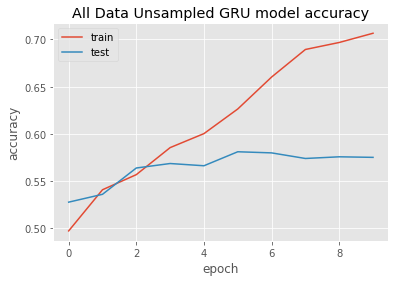

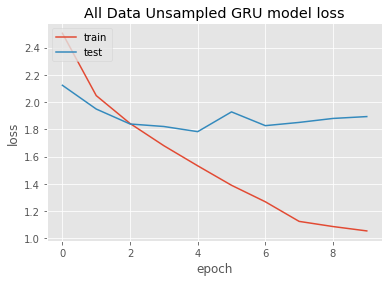

In [ ]:
gruModelRawData.plotModelAccuracy(gruModelRawData_history, 'All Data Unsampled GRU')

In [ ]:
# Check how the GRU Model perform with all the data which is cleansed & resampled to 661 to make the target balance
gruModelAllDataResampled = GruGloveModel()
gruModelAllDataResampled_history, model = gruModelAllDataResampled.train(itTicketDF_resampled,100,epochs)
gruResampled_accuracy = gruModelAllDataResampled.prediction()

Number of Samples: 33050
Number of Labels:  33050
Number of train Samples: 26440
Number of val Samples: 6610
Epoch 1/10
265/265 [==============================] - ETA: 0s - loss: 3.0668 - accuracy: 0.1906
Epoch 00001: val_accuracy improved from -inf to 0.47973, saving model to model-001-0.479728.h5
265/265 [==============================] - 206s 778ms/step - loss: 3.0668 - accuracy: 0.1906 - val_loss: 1.9527 - val_accuracy: 0.4797 - lr: 0.0010
Epoch 2/10
265/265 [==============================] - ETA: 0s - loss: 1.3162 - accuracy: 0.6381
Epoch 00002: val_accuracy improved from 0.47973 to 0.79349, saving model to model-002-0.793495.h5
265/265 [==============================] - 207s 782ms/step - loss: 1.3162 - accuracy: 0.6381 - val_loss: 0.7810 - val_accuracy: 0.7935 - lr: 0.0010
Epoch 3/10
265/265 [==============================] - ETA: 0s - loss: 0.6177 - accuracy: 0.8300
Epoch 00003: val_accuracy improved from 0.79349 to 0.86520, saving model to model-003-0.865204.h5
265/265 [=======

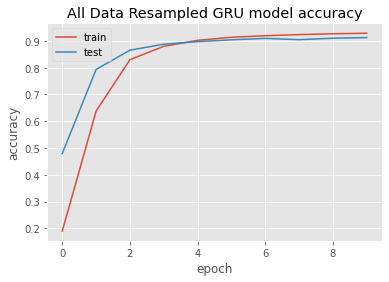

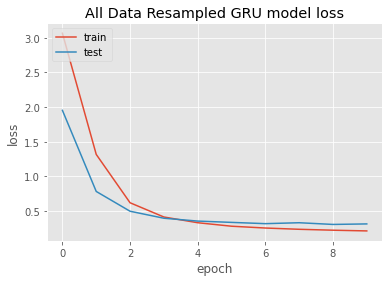

In [ ]:
gruModelAllDataResampled.plotModelAccuracy(gruModelAllDataResampled_history, 'All Data Resampled GRU')

#### Dataframe result capture

In [0]:
results=captureData(results,gruModelRawData_history,'GRU model_GloVe_rawdata','GRU+GloVe Embedding on raw data','7',0)
pred_results= capturePrediction(pred_results,'GRU model_GloVe_rawdata','GRU+GloVe Embedding on raw data','6',gruRaw_accuracy,0)

In [0]:
results=captureData(results,gruModelAllDataResampled_history,'GRU model_GloVe_resampled data','GRU+GloVe Embedding on Augmented data','8',0)
pred_results= capturePrediction(pred_results,'GRU model_GloVe_resampled data','GRU+GloVe Embedding on Augmented data','7',gruResampled_accuracy,0)

### RNN Model 

In [0]:
class RNNGloveModel:
  X_test=[]
  y_test=[]
  embedding_matrix=[]

  def wordTokenizer(self, dataframe):
    tokenizer = Tokenizer(num_words=numWords,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True,split=' ', char_level=False)
    tokenizer.fit_on_texts(dataframe)
    dataframe = tokenizer.texts_to_sequences(dataframe)
    return tokenizer,dataframe

  def tokenizeAndEmbedding(self,dataframe):
    
    tokenizer,X = self.wordTokenizer(dataframe['Description'])
    y = np.asarray(dataframe['Assignment group'])
    X = pad_sequences(X, maxlen = maxlen)

    self.embedding_matrix = np.zeros((numWords+1, 100))
    for i,word in tokenizer.index_word.items():
      if i<numWords+1:
        embedding_vector = embeddings_glove.get(word)
        if embedding_vector is not None:
            self.embedding_matrix[i] = embedding_vector
    return X,y

  def splitData(self,X,y):

    print("Number of Samples:", len(X))
    print("Number of Labels: ", len(y))
    X_train, self.X_test, y_train, self.y_test = train_test_split(X, y, test_size=0.2, random_state=10) # changed by Abraham
    X_train, X_Val, y_train, y_Val = train_test_split(X, y, test_size=0.2, random_state=10)
    print("Number of train Samples:", len(X_train))
    print("Number of val Samples:", len(X_Val))

    return X_train, self.X_test, y_train, self.y_test, X_Val, y_Val

  def train(self, dataframe, batch_size, epochs):
    X,y = self.tokenizeAndEmbedding(dataframe)
    X_train, _, y_train, _, X_Val, y_Val = self.splitData(X,y)

    embed = Embedding(numWords+1,output_dim=100,input_length=maxlen,weights=[self.embedding_matrix], trainable=True)
    model=Sequential()
    model.add(Input(shape=(maxlen,),dtype=tf.int64))
    model.add(embed)
    model.add(Conv1D(100,10,activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(Conv1D(100,10,activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Bidirectional(LSTM(128)))
    model.add(Dropout(0.3))
    model.add(Dense(100,activation='relu'))
    model.add(Dense(len((pd.Series(y_train)).unique()),activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy',optimizer="adam",metrics=['accuracy'])

    model.summary()
    plot_model(model,to_file="RNN.jpg")

    checkpoint = ModelCheckpoint('model-{epoch:03d}-{val_accuracy:03f}.h5', verbose=1, monitor='val_accuracy',save_best_only=True, mode='auto') 
    reduceLoss = ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=2, min_lr=0.0001)
    model_history = model.fit(X_train,y_train,batch_size=batch_size, epochs=epochs, callbacks=[checkpoint,reduceLoss], validation_data=(X_Val, y_Val))
    return model_history, model

  def prediction(self,model):
      
     pred = model.predict(self.X_test)
     pred = [i.argmax() for i in pred]
     accuracy = metrics.accuracy_score(self.y_test, pred)
     print("Accuracy of the model :",accuracy)
     return accuracy

  def plotModelAccuracy(self, history, modelname):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(modelname+' model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(modelname+' model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train','test'], loc='upper left')
    plt.show()

In [ ]:
# Check how the RNN Model perform with the cleansed data
RNNModelRawData = RNNGloveModel()
RNNModelRawData_history, RnnModel = RNNModelRawData.train(itTicketDF,100,epochs)
RNNModelRawData_accuracy = RNNModelRawData.prediction(RnnModel)

Number of Samples: 8439
Number of Labels:  8439
Number of train Samples: 6751
Number of val Samples: 1688
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_8 (Embedding)      (None, 300, 100)          900100    
_________________________________________________________________
conv1d (Conv1D)              (None, 291, 100)          100100    
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 145, 100)          0         
_________________________________________________________________
dropout_8 (Dropout)          (None, 145, 100)          0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 136, 100)          100100    
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 68, 100)           0         
________________

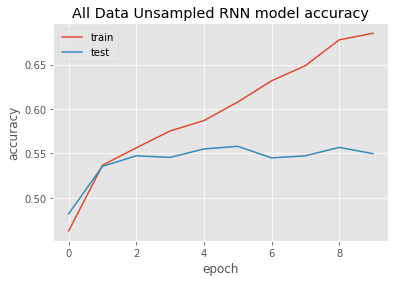

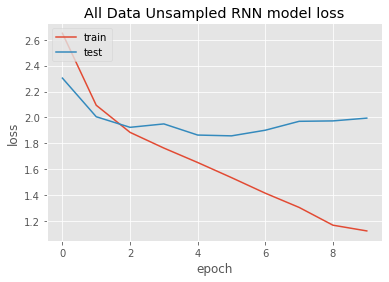

In [ ]:
RNNModelRawData.plotModelAccuracy(RNNModelRawData_history, 'All Data Unsampled RNN')

In [ ]:
#Check how the RNN Model perform with all the data which is cleansed & resampled to 661 to make the target balance
RNNModelAllDataResampled = RNNGloveModel()
RNNModelAllDataResampled_history, RnnModel = RNNModelAllDataResampled.train(itTicketDF_resampled,100,epochs)
RNNModelResampled_accuracy = RNNModelAllDataResampled.prediction(RnnModel)

Number of Samples: 33050
Number of Labels:  33050
Number of train Samples: 26440
Number of val Samples: 6610
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_9 (Embedding)      (None, 300, 100)          900100    
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 291, 100)          100100    
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, 145, 100)          0         
_________________________________________________________________
dropout_10 (Dropout)         (None, 145, 100)          0         
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 136, 100)          100100    
_________________________________________________________________
max_pooling1d_3 (MaxPooling1 (None, 68, 100)           0         
___________

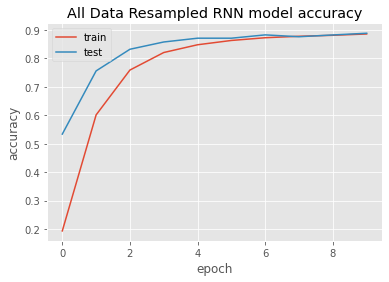

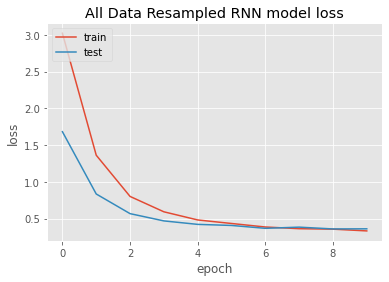

In [ ]:
RNNModelAllDataResampled.plotModelAccuracy(RNNModelAllDataResampled_history, 'All Data Resampled RNN')

#### Dataframe result capture

In [0]:
# results=pd.DataFrame()
results=captureData(results,RNNModelRawData_history,'RNN model_GloVe_rawdata','RNN+GloVe Embedding on raw data','9',0)
pred_results= capturePrediction(pred_results,'RNN model_GloVe_rawdata','RNN+GloVe Embedding on raw data','8',RNNModelRawData_accuracy,0)

In [0]:
results=captureData(results,RNNModelAllDataResampled_history,'RNN model_GloVe_resampled data','RNN+GloVe Embedding on Augmented data','10',0)
pred_results= capturePrediction(pred_results,'RNN model_GloVe_resampled data','RNN+GloVe Embedding on Augmented data','9',RNNModelResampled_accuracy,0)

In [ ]:
results

,model,val_accuracy,val_loss,loss,accuracy,descriptions
1,LSTM model_WV_rawdata,0.579976,1.831799,1.368159,0.636054,LSTM+Word2Vec Embedding on raw data
2,LSTM model_WV_resampled data,0.911346,0.303620,0.237115,0.922504,LSTM+Word2Vec Embedding on Augmented data
3,LSTM 2 part model_WV_grp0,0.938643,0.193967,0.073982,0.972977,LSTM+Word2Vec Embedding on grp0_data
4,LSTM 2 part model_WV_Others,0.724455,0.893221,0.597537,0.771313,LSTM+Word2Vec Embedding on Rest of groups
5,LSTM model_GloVe_rawdata,0.603673,1.608947,1.208922,0.671900,LSTM+GloVe Embedding on raw data
6,LSTM model_GloVe_resampled data,0.914826,0.273002,0.218702,0.927383,LSTM+GloVe Embedding on Augmented data
7,GRU model_GloVe_rawdata,0.581161,1.928621,1.389953,0.626426,GRU+GloVe Embedding on raw data
8,GRU model_GloVe_resampled data,0.912405,0.312108,0.210933,0.928593,GRU+GloVe Embedding on Augmented data
9,RNN model_GloVe_rawdata,0.558057,1.858335,1.536040,0.607910,RNN+GloVe Embedding on raw data
10,RNN model_GloVe_resampled data,0.888200,0.359622,0.331052,0.885628,RNN+GloVe Embedding on Augmented data


In [ ]:
pred_results

,model,Pred_Accuracy,descriptions
1,LSTM model_WV_rawdata,0.576422,LSTM+Word2Vec Embedding on raw data
2,LSTM model_WV_resampled data,0.911346,LSTM+Word2Vec Embedding on Augmented data
3,LSTM 2 part model_WV,0.278139,LSTM+Word2Vec Embedding on Augmented data
4,LSTM model_GloVe_rawdata,0.590047,LSTM+GloVe Embedding on raw data
5,LSTM model_GloVe_resampled data,0.914826,LSTM+GloVe Embedding on Augmented data
6,GRU model_GloVe_rawdata,0.575237,GRU+GloVe Embedding on raw data
7,GRU model_GloVe_resampled data,0.912405,GRU+GloVe Embedding on Augmented data
8,RNN model_GloVe_rawdata,0.549763,RNN+GloVe Embedding on raw data
9,RNN model_GloVe_resampled data,0.888200,RNN+GloVe Embedding on Augmented data


## Traditional ML/Random forest

#### Observation:
 - Random Forest Model using raw data seems to perform better as compared to Random Forest Model with PCA done.
 - It also affirm the understanding that PCA uses linearity in the data to reduce dimensionality, where as the problems such NLP uses the non-linearity of feature.


In [0]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [0]:
def wordTokenizer(dataframe):
    tokenizer = Tokenizer(num_words=numWords,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True,split=' ', char_level=False)
    tokenizer.fit_on_texts(dataframe)
    dataframe = tokenizer.texts_to_sequences(dataframe)
    return tokenizer,dataframe

In [ ]:
maxlen = 150
numWords = 9000
tokenizer,X = wordTokenizer(itTicketDF['Description'])
y = np.asarray(itTicketDF['Assignment group'])
X = pad_sequences(X, maxlen = maxlen)

print("Number of Samples:", len(X))
print("Number of Labels: ", len(y))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
print("Number of train Samples:", len(X_train))
print("Number of val Samples:", len(X_test))

Number of Samples: 8439
Number of Labels:  8439
Number of train Samples: 6751
Number of val Samples: 1688


### Random Forest Model on the Raw data

In [ ]:
rawClf=RandomForestClassifier(n_estimators=100)
rawClf.fit(X_train,y_train)
y_pred=rawClf.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.5758293838862559


In [ ]:
#Store the accuracy results for each model in a dataframe for final comparison
results_ml=pd.DataFrame()
tempResultsDf_ml = pd.DataFrame({'Model':['Random Forest'], 'accuracy': [metrics.accuracy_score(y_test, y_pred)]},index={'1'})
results_ml = pd.concat([results_ml, tempResultsDf_ml])
results_ml

,Model,accuracy
1,Random Forest,0.575829


### SVM Classifier model

In [ ]:
Cs = [0.01, 0.1, 1, 10]
gammas = [0.001, 0.01, 0.1, 1]
param_grid = {'C': Cs, 'gamma' : gammas}
svc = svm.SVC(kernel='rbf')
grid_search = GridSearchCV(svc, param_grid)
grid_search.fit(X_train,y_train)

clf = svm.SVC(**grid_search.best_params_)
clf.fit(X_train, y_train)

SVC(C=1, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=0.1, kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [0]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.5562796208530806

In [ ]:
#Store the accuracy results for each model in a dataframe for final comparison
tempResultsDf_ml = pd.DataFrame({'Model':['SVM Classifier'], 'accuracy': [metrics.accuracy_score(y_test, y_pred)]},index={'2'})
results_ml = pd.concat([results_ml, tempResultsDf_ml])
results_ml

,Model,accuracy
1,Random Forest,0.575829
2,SVM Classifier,0.556280
